# Selective feature unlearning

In this notebook, the experiments focus on unlearning of a feature rather than complete samples. The feature of interest is age, since within the subgroup of samples with age ≤30, there may exist a correlation between younger age and an increased probability of assigning category 8 (Nevus). This subgroup also exhibited comparatively high TPR values in previous experiments, suggesting that age-related information may contribute strongly to the classification process.

For these experiments, the forget set selected corresponds to the progressive unlearning configuration containing 50% random and 50% rare samples (age ≤30). According to the previously analysed metrics, this configuration produced the lowest values for the combined measures (1−forgetness)⋅utility and (1−forgetness)⋅utility⋅(1−Average EO Gap). Consequently, this setting represents one of the most challenging trade-offs between forgetting performance, predictive utility, and fairness preservation.

Selecting this configuration allows the feature-unlearning experiments to be evaluated under conditions where the effect of forgetting is expected to be most pronounced. In particular, it provides an opportunity to investigate whether selective removal of age-related information can mitigate the observed dependency on younger age groups while preserving the predictive contribution of the remaining metadata attributes.

In [1]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

WORK_DIR_ROOT = '/content/drive/MyDrive/datasets/Master/'
sys.path.append(WORK_DIR_ROOT)

from utils import *


DATASET_ROOT = '/content/drive/MyDrive/datasets/Master/datasets_orig'
METADATA_TRAIN_PATH = f"{DATASET_ROOT}/MILK10k_Training_Metadata.csv"
METADATA_TEST_PATH = f"{DATASET_ROOT}/MILK10k_Test_Metadata.csv"
DATASET_TRAIN = f"{DATASET_ROOT}/MILK10k_Training_Input/MILK10k_Training_Input/"
DATASET_RESIZED = f"{WORK_DIR_ROOT}/datasets_resized_stratified/"
GT_PATH = f"{DATASET_ROOT}/MILK10k_Training_GroundTruth.csv"


CHECKPOINT_DIR = WORK_DIR_ROOT + 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "skin_tone_class", "sex", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

#print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
#print(df_train_dermoscopic_minimal.head())

#print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

Import the lession Ids split

In [4]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)


# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)

# Train
df_train_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

# Train
df_train_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)


Lesions - Train: 4191, Val: 524, Test: 525


Load the mapping between metadata values and their location in the one-hot-encoding vector

In [5]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


Create validation dataset and loader, since it is reused.

In [6]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

validation_transform = transforms.Compose([
    transforms.ToTensor()])

# using the validation as usual.
val_dataset = Milk10kDataset_3_modalities(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)

NUM_WORKERS = os.cpu_count()
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

## Load the 50% rare and 50% random forget set split ids

In [ ]:
forget_lesions, retain_lesions = create_unlearning_split_youth(
    young_ratio=0.5,
    split_filename="unlearning_split_age_50_ran_50.json"
)

Loading existing split: unlearning_split_age_50_ran_50.json
  Forget: 225 | Retain: 3966


Analyse the distribution of both rare and random samples in the forget set:

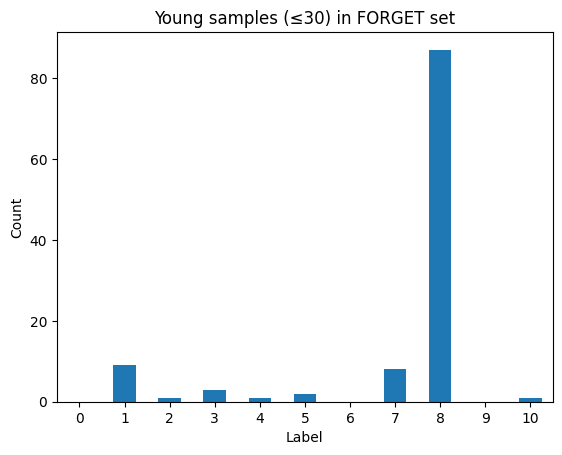

In [ ]:
df_train_only = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(train_lesions)
]

df_forget = df_train_only[df_train_only["lesion_id"].isin(forget_lesions)]

df_forget_young = df_forget[df_forget["age_approx"] <= 30]

counts = df_forget_young["label_id"].value_counts()
counts = counts.reindex(range(11), fill_value=0)

counts.plot(kind="bar")
plt.title("Young samples (≤30) in FORGET set")
plt.xlabel("Label")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.show()

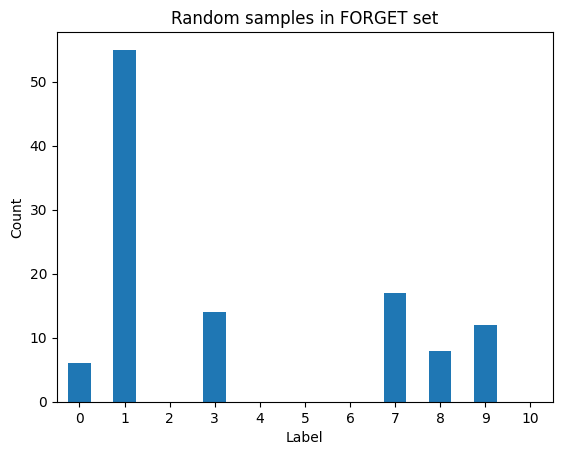

In [ ]:
df_forget_random = df_forget[df_forget["age_approx"] > 30] # the rest of the samples, since when
# selecting the random samples we don't select from those <=30.

counts = df_forget_random["label_id"].value_counts()
counts = counts.reindex(range(11), fill_value=0)

counts.plot(kind="bar")
plt.title("Random samples in FORGET set")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

Print age subgroups of the forget set:

31-39      2
41-49     11
51-59     14
61-69     30
71-79     29
<=30     112
>80       26
dtype: int64


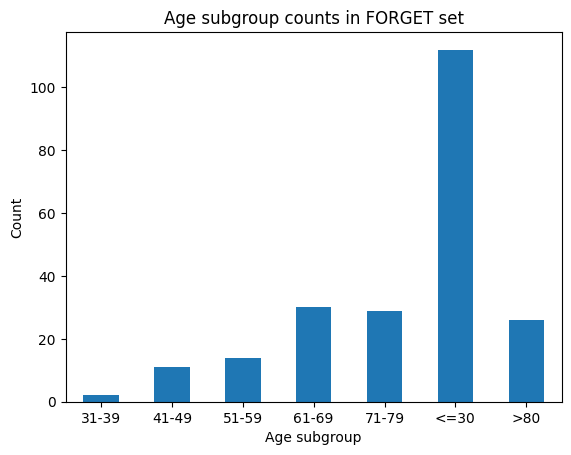

In [ ]:

# Keep only random forget samples above 30

# Define age subgroup mapping
age_bins = {
    "31-39": (31, 39),
    "41-49": (40, 49),
    "51-59": (50, 59),
    "61-69": (60, 69),
    "71-79": (70, 79),
    "<=30": (0, 30),
    ">80": (80, 200)
}

# Count samples in each subgroup
age_counts = {}

for group_name, (low, high) in age_bins.items():
    count = df_forget[
        (df_forget["age_approx"] >= low) &
        (df_forget["age_approx"] <= high)
    ].shape[0]

    age_counts[group_name] = count

# Convert to Series for plotting
age_counts_series = pd.Series(age_counts)

print(age_counts_series)

# Plot
age_counts_series.plot(kind="bar")

plt.title("Age subgroup counts in FORGET set")
plt.xlabel("Age subgroup")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

## Prepare the loaders for the retrained model



The new dataset class implements feature-level unlearning over the metadata representation. Unlike sample-level unlearning, here all training samples are retained, but specific metadata attributes are selectively modified for a defined subset of lesion IDs - the forgetset.

Again, the metadata is encoded using a softened one-hot representation, where a smoothing parameter assigns a high value to the active category and a small baseline value to inactive categories.

For selected samples and metadata fields (the forgetset), the corresponding attribute signal is "forgotten" by replacing the active encoding with the baseline value. This allows the model to be retrained while reducing the influence of specific metadata features, such as age, without removing entire samples.

In [ ]:
# we chose the age metadata column
forget_meta_cols = ["age_approx"]

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()])

In [ ]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# we use the training data set as original, however we provide the metadata cols and lession Ids to which we
# want to apply forgetting.

train_dataset = Milk10kDataset_3_modalities_feature_unlearning(
    df_train_clinical,
    df_train_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=train_transform,
    forget_lesion_ids=forget_lesions,
    forget_metadata_cols=forget_meta_cols
)

NUM_WORKERS = os.cpu_count()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)


Using device: cuda


## (0) Train the Reference model
Process similar to the original trianing of Model 8, however here we modify the samples with lessionIds from the feature unlearning set to miss value for the age metadata.

Using device: cuda

Run 1/3
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 65.2MB/s]


Epoch [1/1000] | Train Loss: 1.4992 | Val Loss: 1.2254 | Val Acc: 0.6221
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1326 | Val Loss: 1.0649 | Val Acc: 0.6718
Best model + history saved
Epoch [3/1000] | Train Loss: 1.0370 | Val Loss: 1.0138 | Val Acc: 0.6737
Best model + history saved
Epoch [4/1000] | Train Loss: 0.9886 | Val Loss: 1.0151 | Val Acc: 0.6431
Epoch [5/1000] | Train Loss: 0.9441 | Val Loss: 0.9624 | Val Acc: 0.6870
Best model + history saved
Epoch [6/1000] | Train Loss: 0.9095 | Val Loss: 0.9941 | Val Acc: 0.6622
Epoch [7/1000] | Train Loss: 0.8855 | Val Loss: 0.9465 | Val Acc: 0.6794
Best model + history saved
Epoch [8/1000] | Train Loss: 0.8733 | Val Loss: 0.9340 | Val Acc: 0.6927
Best model + history saved
Epoch [9/1000] | Train Loss: 0.8373 | Val Loss: 0.9913 | Val Acc: 0.6756
Epoch [10/1000] | Train Loss: 0.8241 | Val Loss: 0.9524 | Val Acc: 0.6775
Epoch [11/1000] | Train Loss: 0.7814 | Val Loss: 0.9198 | Val Acc: 0.6794
Best model + history saved
Epoch 

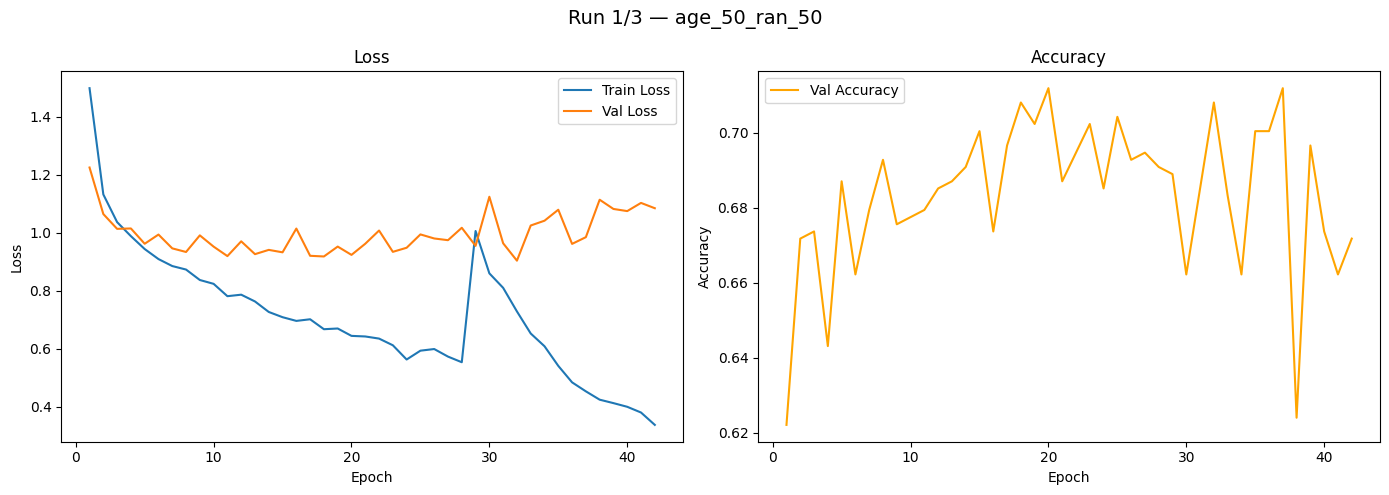


Run 2/3
Epoch [1/1000] | Train Loss: 1.4527 | Val Loss: 1.1770 | Val Acc: 0.6374
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1170 | Val Loss: 1.0715 | Val Acc: 0.6489
Best model + history saved
Epoch [3/1000] | Train Loss: 1.0347 | Val Loss: 1.0352 | Val Acc: 0.6698
Best model + history saved
Epoch [4/1000] | Train Loss: 0.9921 | Val Loss: 1.0085 | Val Acc: 0.6698
Best model + history saved
Epoch [5/1000] | Train Loss: 0.9481 | Val Loss: 0.9848 | Val Acc: 0.6756
Best model + history saved
Epoch [6/1000] | Train Loss: 0.9385 | Val Loss: 1.0057 | Val Acc: 0.6679
Epoch [7/1000] | Train Loss: 0.9247 | Val Loss: 0.9425 | Val Acc: 0.6641
Best model + history saved
Epoch [8/1000] | Train Loss: 0.8757 | Val Loss: 0.9564 | Val Acc: 0.6870
Epoch [9/1000] | Train Loss: 0.8368 | Val Loss: 0.9401 | Val Acc: 0.6947
Best model + history saved
Epoch [10/1000] | Train Loss: 0.8335 | Val Loss: 0.9109 | Val Acc: 0.6947
Best model + history saved
Epoch [11/1000] | Train Loss: 0.7999 | Val L

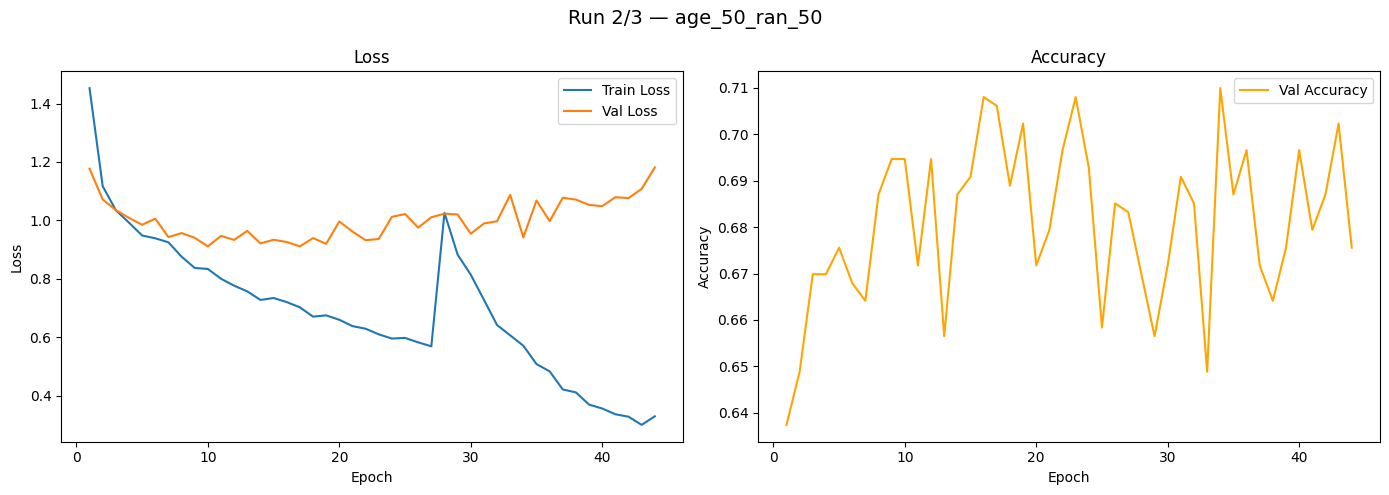


Run 3/3
Epoch [1/1000] | Train Loss: 1.5159 | Val Loss: 1.2170 | Val Acc: 0.6298
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1458 | Val Loss: 1.0434 | Val Acc: 0.6775
Best model + history saved
Epoch [3/1000] | Train Loss: 1.0434 | Val Loss: 1.0478 | Val Acc: 0.6622
Epoch [4/1000] | Train Loss: 0.9832 | Val Loss: 1.0032 | Val Acc: 0.6679
Best model + history saved
Epoch [5/1000] | Train Loss: 0.9492 | Val Loss: 0.9738 | Val Acc: 0.6756
Best model + history saved
Epoch [6/1000] | Train Loss: 0.9034 | Val Loss: 0.9558 | Val Acc: 0.6889
Best model + history saved
Epoch [7/1000] | Train Loss: 0.8973 | Val Loss: 1.0055 | Val Acc: 0.6603
Epoch [8/1000] | Train Loss: 0.8565 | Val Loss: 0.9175 | Val Acc: 0.7042
Best model + history saved
Epoch [9/1000] | Train Loss: 0.8347 | Val Loss: 0.9222 | Val Acc: 0.6947
Epoch [10/1000] | Train Loss: 0.8170 | Val Loss: 0.9533 | Val Acc: 0.6794
Epoch [11/1000] | Train Loss: 0.7948 | Val Loss: 0.9447 | Val Acc: 0.6718
Epoch [12/1000] | Train 

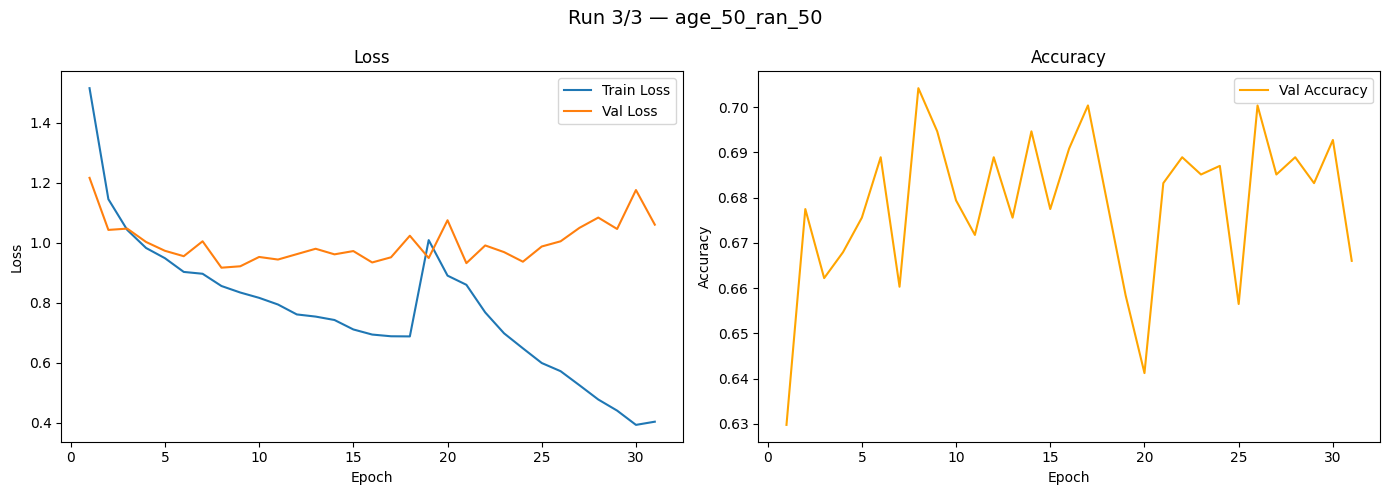

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

best_lr_head = 0.00030995448268009645
best_lr_full = 5.816190742383745e-05


NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    wrapper_model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    # Stage 1: Head only
    freeze_backbone_3_modalities(wrapper_model)
    optimizer_stage1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, wrapper_model.parameters()),
        lr=best_lr_head
    )
    wrapper_model, history_stage1 = train_model_3_modalities(
        wrapper_model, train_loader, val_loader, criterion,
        optimizer_stage1, device, epochs=1000, patience=10,
        save_path=f"{CHECKPOINT_DIR}/Retrained_feature_unlearning_age_run{run_idx}_stage1.pt"
    )
    del optimizer_stage1
    torch.cuda.empty_cache()

    # Stage 2: Full model
    unfreeze_all_3_modalities(wrapper_model)
    optimizer_stage2 = torch.optim.AdamW(
        wrapper_model.parameters(),
        lr=best_lr_full
    )
    wrapper_model, history_stage2 = train_model_3_modalities(
        wrapper_model, train_loader, val_loader, criterion,
        optimizer_stage2, device, epochs=1000, patience=10,
        save_path=f"{CHECKPOINT_DIR}/Retrained_feature_unlearning_age_run{run_idx}_stage2.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")

    all_histories[run_idx] = {
        "train_loss": history_stage1["train_loss"] + history_stage2["train_loss"],
        "val_loss":   history_stage1["val_loss"]   + history_stage2["val_loss"],
        "val_acc":    history_stage1["val_acc"]     + history_stage2["val_acc"],
    }


    # Plot after run
    epochs_x = range(1, len(all_histories[run_idx]["train_loss"]) + 1)
    history = all_histories[run_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Run {run_idx}/{NUM_RUNS} — age_50_ran_50", fontsize=14)

    axes[0].plot(epochs_x, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_x, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs_x, history["val_acc"], label="Val Accuracy", color="orange")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Clean up memory before next run
    del wrapper_model, optimizer_stage2, criterion
    del history_stage1, history_stage2
    torch.cuda.empty_cache()
    gc.collect()


## (1) Finetuning 1 epoch
The samples for the unlearned features are modified to remove the information for the age by setting all values of the one-hot encoding vector to a small constant (because I use soft label encoding).

Using device: cuda

Run 1/3
Epoch [1/1] | Train Loss: 1.9952 | Val Loss: 1.6523 | Val Acc: 0.5992
Best model + history saved

Run 1 finished in 6.52 minutes


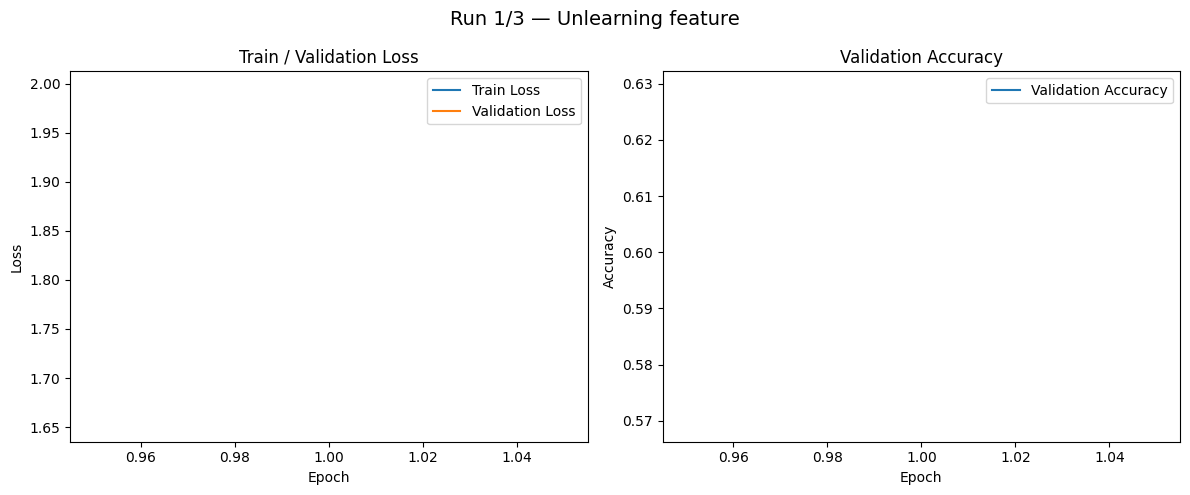

Memory cleaned after run 1

Run 2/3
Epoch [1/1] | Train Loss: 1.5958 | Val Loss: 1.2559 | Val Acc: 0.6985
Best model + history saved

Run 2 finished in 6.32 minutes


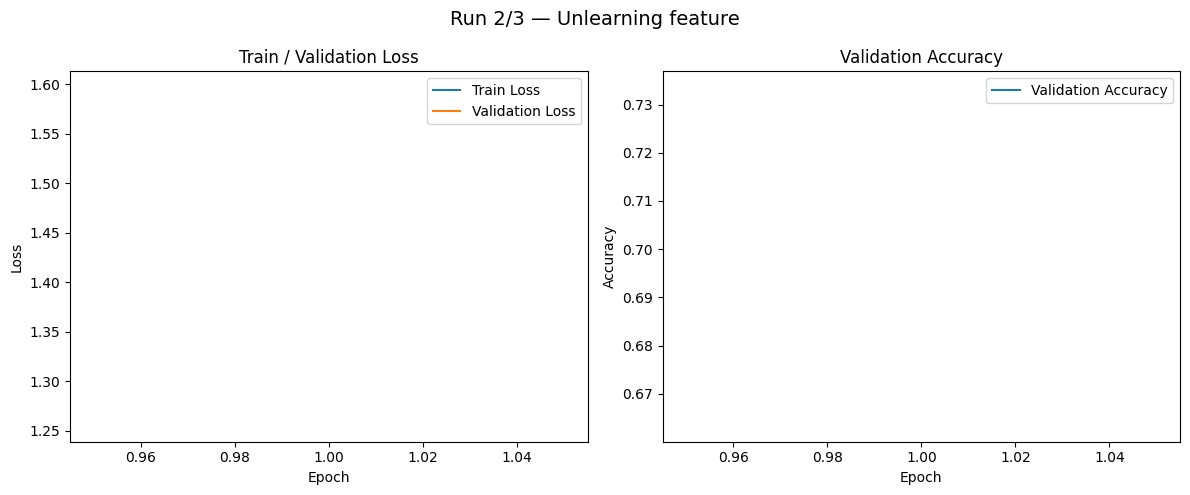

Memory cleaned after run 2

Run 3/3
Epoch [1/1] | Train Loss: 1.9145 | Val Loss: 1.5115 | Val Acc: 0.5782
Best model + history saved

Run 3 finished in 6.42 minutes


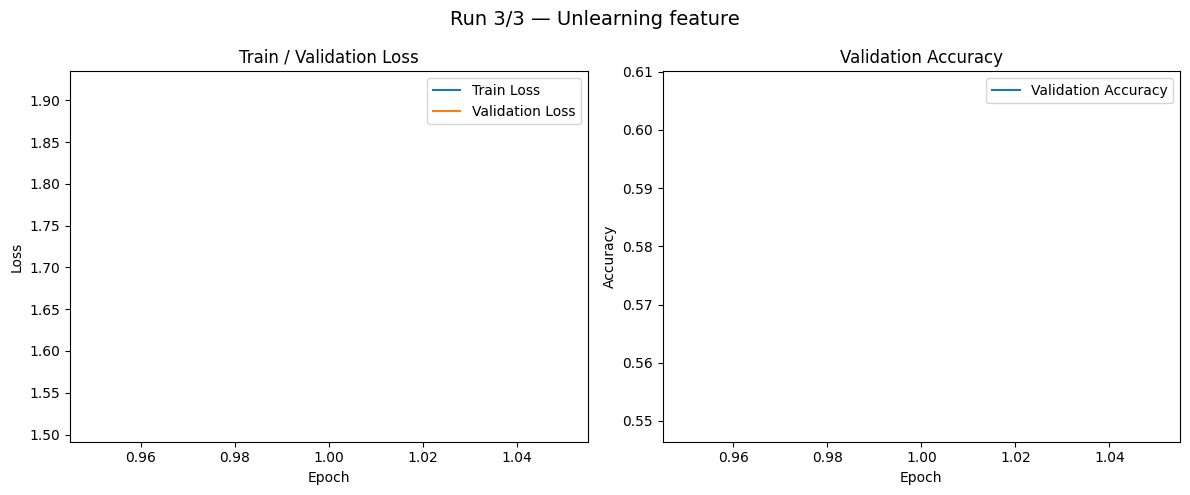

Memory cleaned after run 3


In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

SAVE_EPOCH = 1
best_lr_full = 5.816190742383745e-05


NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    wrapper_model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim, num_classes=11
    ).to(device)
    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_images_metadata_1_best_stage2.pt",
        map_location=device, weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()
    unfreeze_all_3_modalities(wrapper_model)
    wrapper_model.head[-1].reset_parameters()

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_full)


    wrapper_model, history = train_model_3_modalities(
        model=wrapper_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=SAVE_EPOCH,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_feature_unlearning_age_1_epoch_run{run_idx}.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")


    # --- Plot immediately ---
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
       f"Run {run_idx}/{NUM_RUNS} — Unlearning feature",
       fontsize=14
    )

    # Loss plot

    axes[0].plot(
       epochs_x,
       history["train_loss"],
       label="Train Loss"
    )

    axes[0].plot(
      epochs_x,
      history["val_loss"],
      label="Validation Loss"
    )

    axes[0].set_title("Train / Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # -----------------------------
    # Accuracy plot
    # -----------------------------

    axes[1].plot(
        epochs_x,
        history["val_acc"],
        label="Validation Accuracy"
    )

    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Clean up ---
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")

## (1) Finetuning 3 epochs
The samples for the unlearned features are modified to remove the information for the age by setting all values of the one-hot encoding vector to a small constant (because I use soft label encoding).

Using device: cuda

Run 1/3
Epoch [1/3] | Train Loss: 1.7992 | Val Loss: 1.3827 | Val Acc: 0.6298
Best model + history saved
Epoch [2/3] | Train Loss: 1.2369 | Val Loss: 1.2027 | Val Acc: 0.6870
Best model + history saved
Epoch [3/3] | Train Loss: 0.9882 | Val Loss: 1.1744 | Val Acc: 0.6565
Best model + history saved

Run 1 finished in 19.53 minutes


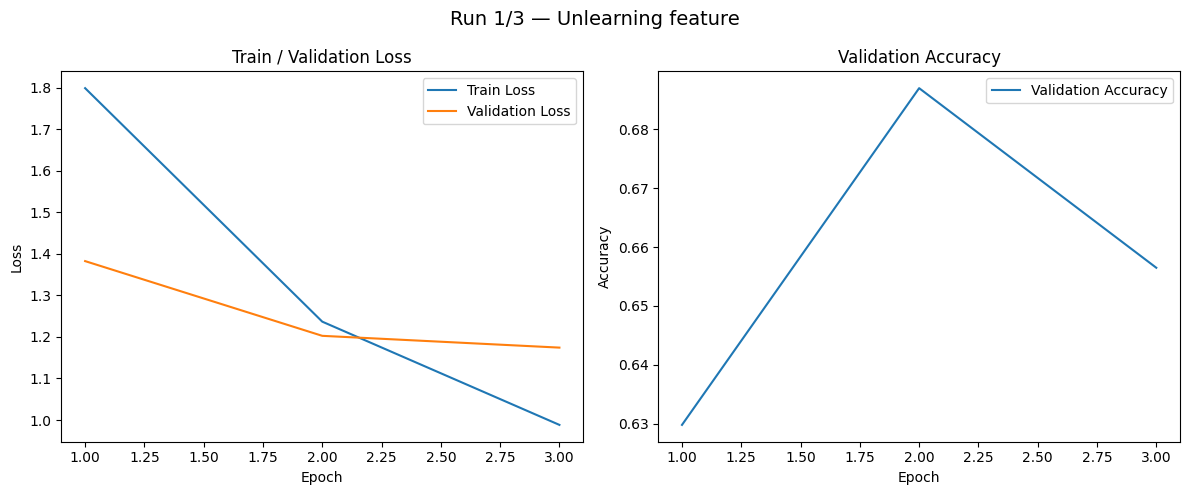

Memory cleaned after run 1

Run 2/3
Epoch [1/3] | Train Loss: 1.6882 | Val Loss: 1.5534 | Val Acc: 0.6069
Best model + history saved
Epoch [2/3] | Train Loss: 1.1174 | Val Loss: 1.2537 | Val Acc: 0.6603
Best model + history saved
Epoch [3/3] | Train Loss: 0.8780 | Val Loss: 1.2348 | Val Acc: 0.6317
Best model + history saved

Run 2 finished in 20.37 minutes


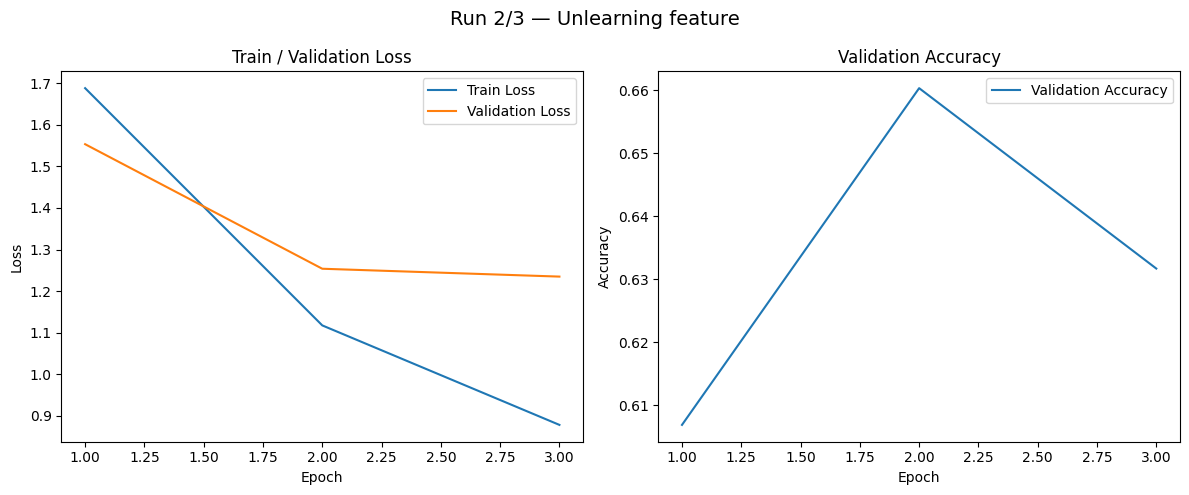

Memory cleaned after run 2

Run 3/3
Epoch [1/3] | Train Loss: 1.7201 | Val Loss: 1.4129 | Val Acc: 0.6603
Best model + history saved
Epoch [2/3] | Train Loss: 1.1416 | Val Loss: 1.1231 | Val Acc: 0.6870
Best model + history saved
Epoch [3/3] | Train Loss: 0.9256 | Val Loss: 1.0812 | Val Acc: 0.6908
Best model + history saved

Run 3 finished in 20.35 minutes


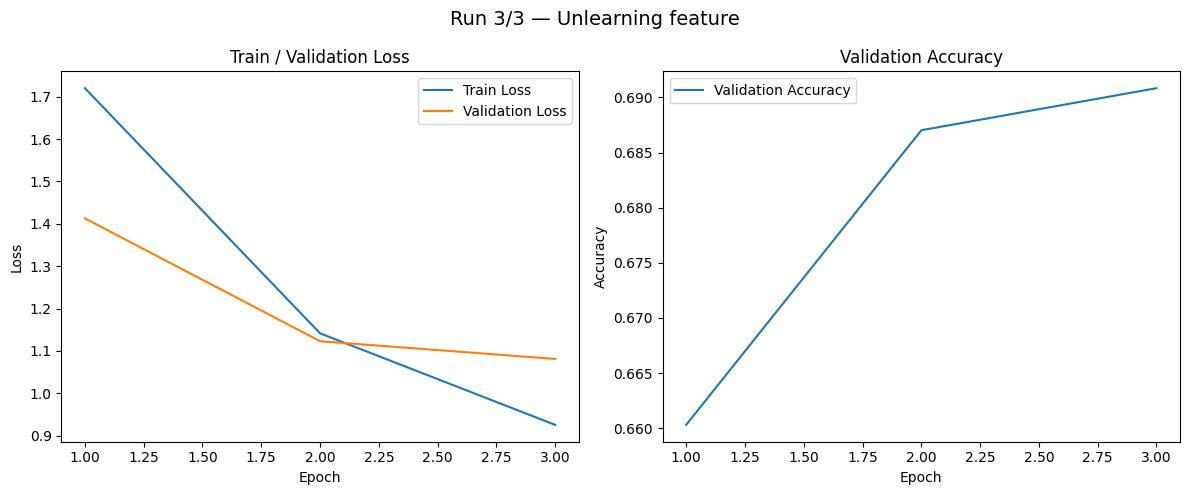

Memory cleaned after run 3


In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

SAVE_EPOCH = 3
best_lr_full = 5.816190742383745e-05


NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    wrapper_model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim, num_classes=11
    ).to(device)
    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_images_metadata_1_best_stage2.pt",
        map_location=device, weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()
    unfreeze_all_3_modalities(wrapper_model)
    wrapper_model.head[-1].reset_parameters()

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_full)


    wrapper_model, history = train_model_3_modalities(
        model=wrapper_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=SAVE_EPOCH,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_feature_unlearning_age_3_epochs_run{run_idx}.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")


    # --- Plot immediately ---
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
       f"Run {run_idx}/{NUM_RUNS} — Unlearning feature",
       fontsize=14
    )

    # Loss plot

    axes[0].plot(
       epochs_x,
       history["train_loss"],
       label="Train Loss"
    )

    axes[0].plot(
      epochs_x,
      history["val_loss"],
      label="Validation Loss"
    )

    axes[0].set_title("Train / Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # -----------------------------
    # Accuracy plot
    # -----------------------------

    axes[1].plot(
        epochs_x,
        history["val_acc"],
        label="Validation Accuracy"
    )

    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Clean up ---
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")

## (2) Finetuning 4 epochs

Using device: cuda

Run 1/3
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 153MB/s]


Epoch [1/4] | Train Loss: 1.6597 | Val Loss: 1.3700 | Val Acc: 0.6412
Best model + history saved
Epoch [2/4] | Train Loss: 1.0962 | Val Loss: 1.1424 | Val Acc: 0.6718
Best model + history saved
Epoch [3/4] | Train Loss: 0.8653 | Val Loss: 1.1035 | Val Acc: 0.6508
Best model + history saved
Epoch [4/4] | Train Loss: 0.7649 | Val Loss: 1.1148 | Val Acc: 0.6450

Run 1 finished in 46.47 minutes


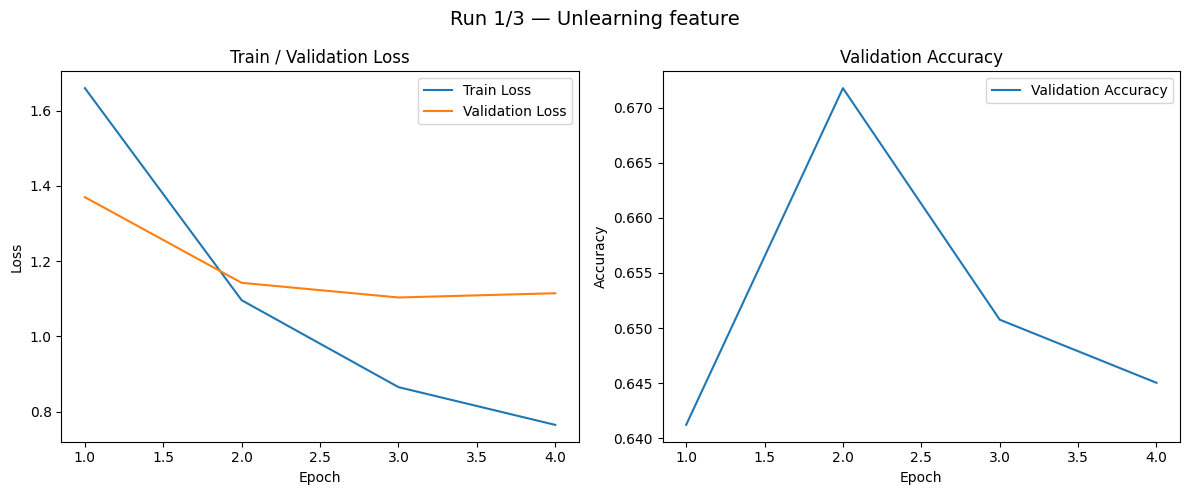

Memory cleaned after run 1

Run 2/3
Epoch [1/4] | Train Loss: 1.7115 | Val Loss: 1.3653 | Val Acc: 0.6469
Best model + history saved
Epoch [2/4] | Train Loss: 1.1642 | Val Loss: 1.1465 | Val Acc: 0.6927
Best model + history saved
Epoch [3/4] | Train Loss: 0.9522 | Val Loss: 1.1238 | Val Acc: 0.6737
Best model + history saved
Epoch [4/4] | Train Loss: 0.7732 | Val Loss: 1.1145 | Val Acc: 0.6622
Best model + history saved

Run 2 finished in 25.37 minutes


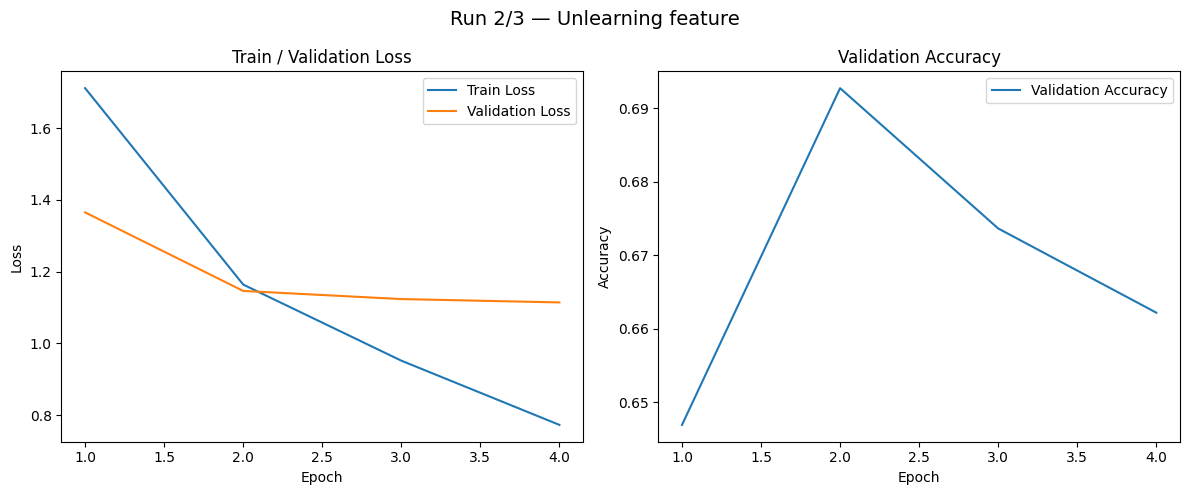

Memory cleaned after run 2

Run 3/3
Epoch [1/4] | Train Loss: 1.7580 | Val Loss: 1.4331 | Val Acc: 0.6336
Best model + history saved
Epoch [2/4] | Train Loss: 1.1592 | Val Loss: 1.2178 | Val Acc: 0.6527
Best model + history saved
Epoch [3/4] | Train Loss: 0.9282 | Val Loss: 1.0432 | Val Acc: 0.7023
Best model + history saved
Epoch [4/4] | Train Loss: 0.7764 | Val Loss: 1.0309 | Val Acc: 0.6794
Best model + history saved

Run 3 finished in 26.80 minutes


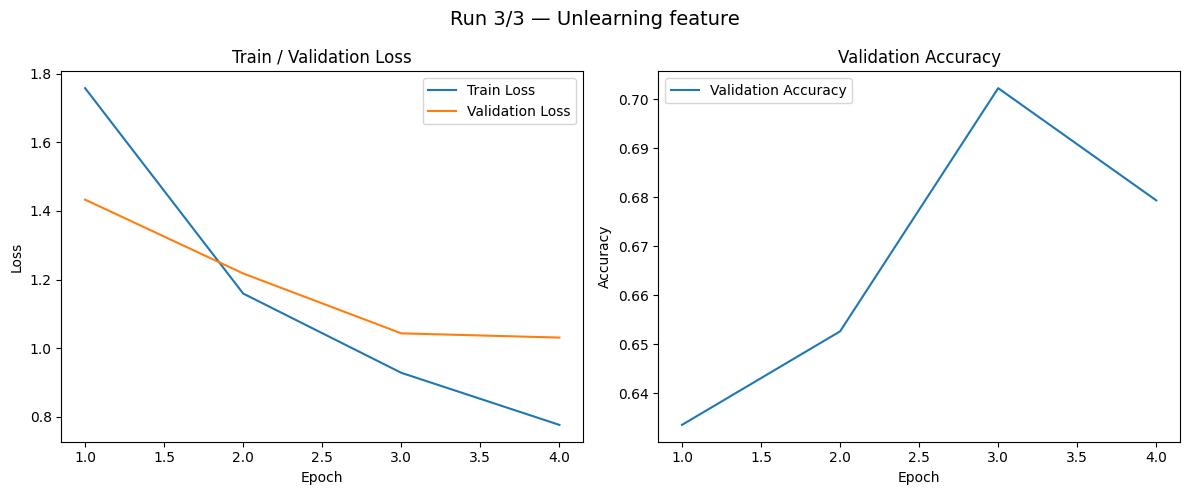

Memory cleaned after run 3


In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

SAVE_EPOCH = 4
best_lr_full = 5.816190742383745e-05


NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    wrapper_model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim, num_classes=11
    ).to(device)
    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_images_metadata_1_best_stage2.pt",
        map_location=device, weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()
    unfreeze_all_3_modalities(wrapper_model)
    wrapper_model.head[-1].reset_parameters()

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_full)


    wrapper_model, history = train_model_3_modalities(
        model=wrapper_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=SAVE_EPOCH,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_feature_unlearning_age_4_epochs_run{run_idx}.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")


    # --- Plot immediately ---
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
       f"Run {run_idx}/{NUM_RUNS} — Unlearning feature",
       fontsize=14
    )

    # Loss plot

    axes[0].plot(
       epochs_x,
       history["train_loss"],
       label="Train Loss"
    )

    axes[0].plot(
      epochs_x,
      history["val_loss"],
      label="Validation Loss"
    )

    axes[0].set_title("Train / Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # -----------------------------
    # Accuracy plot
    # -----------------------------

    axes[1].plot(
        epochs_x,
        history["val_acc"],
        label="Validation Accuracy"
    )

    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Clean up ---
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")

## Perturbation

## (3) Fine-tuning - Perturbation finetune custom head only


Using device: cuda

Run 1/3
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 172MB/s]


Epoch [1/50] | Train Loss: 0.9465 | Val Loss: 0.9802 | Val Acc: 0.7042
Best model + history saved
Epoch [2/50] | Train Loss: 0.5168 | Val Loss: 0.9801 | Val Acc: 0.7061
Best model + history saved
Epoch [3/50] | Train Loss: 0.4635 | Val Loss: 1.0735 | Val Acc: 0.6851
Epoch [4/50] | Train Loss: 0.4277 | Val Loss: 1.0127 | Val Acc: 0.7004
Epoch [5/50] | Train Loss: 0.3903 | Val Loss: 1.0749 | Val Acc: 0.6889
Epoch [6/50] | Train Loss: 0.3939 | Val Loss: 1.0860 | Val Acc: 0.7137
Epoch [7/50] | Train Loss: 0.3687 | Val Loss: 1.0719 | Val Acc: 0.6851
Epoch [8/50] | Train Loss: 0.3602 | Val Loss: 1.0767 | Val Acc: 0.6851
Epoch [9/50] | Train Loss: 0.3543 | Val Loss: 1.0744 | Val Acc: 0.7080
Epoch [10/50] | Train Loss: 0.3420 | Val Loss: 1.0953 | Val Acc: 0.7023
Epoch [11/50] | Train Loss: 0.3242 | Val Loss: 1.0954 | Val Acc: 0.6966
Epoch [12/50] | Train Loss: 0.3204 | Val Loss: 1.1361 | Val Acc: 0.7061
Early stopping triggered

Run 1 finished in 94.82 minutes


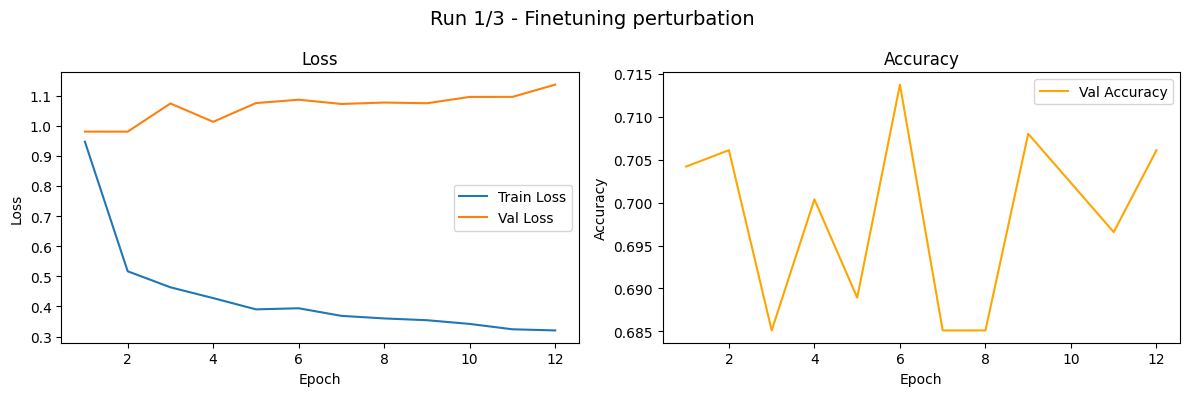

Memory cleaned after run 1

Run 2/3
Epoch [1/50] | Train Loss: 0.9681 | Val Loss: 0.9943 | Val Acc: 0.6985
Best model + history saved
Epoch [2/50] | Train Loss: 0.5389 | Val Loss: 1.0447 | Val Acc: 0.6927
Epoch [3/50] | Train Loss: 0.4618 | Val Loss: 1.0035 | Val Acc: 0.7061
Epoch [4/50] | Train Loss: 0.4638 | Val Loss: 1.0031 | Val Acc: 0.7042
Epoch [5/50] | Train Loss: 0.4137 | Val Loss: 1.0522 | Val Acc: 0.6851
Epoch [6/50] | Train Loss: 0.3739 | Val Loss: 1.0792 | Val Acc: 0.7023
Epoch [7/50] | Train Loss: 0.3611 | Val Loss: 1.0622 | Val Acc: 0.7042
Epoch [8/50] | Train Loss: 0.3580 | Val Loss: 1.0465 | Val Acc: 0.7137
Epoch [9/50] | Train Loss: 0.3299 | Val Loss: 1.0871 | Val Acc: 0.7042
Epoch [10/50] | Train Loss: 0.3394 | Val Loss: 1.1280 | Val Acc: 0.7004
Epoch [11/50] | Train Loss: 0.3226 | Val Loss: 1.1479 | Val Acc: 0.7042
Early stopping triggered

Run 2 finished in 26.90 minutes


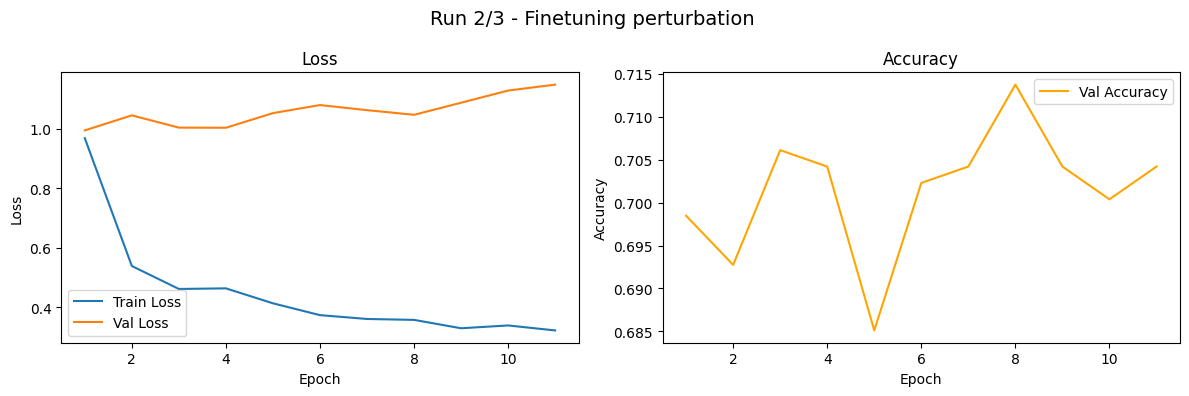

Memory cleaned after run 2

Run 3/3
Epoch [1/50] | Train Loss: 0.9470 | Val Loss: 1.0021 | Val Acc: 0.7099
Best model + history saved
Epoch [2/50] | Train Loss: 0.5370 | Val Loss: 0.9774 | Val Acc: 0.6985
Best model + history saved
Epoch [3/50] | Train Loss: 0.4460 | Val Loss: 1.0266 | Val Acc: 0.6775
Epoch [4/50] | Train Loss: 0.4356 | Val Loss: 1.0112 | Val Acc: 0.7042
Epoch [5/50] | Train Loss: 0.4034 | Val Loss: 1.0232 | Val Acc: 0.6985
Epoch [6/50] | Train Loss: 0.3854 | Val Loss: 1.0583 | Val Acc: 0.7042
Epoch [7/50] | Train Loss: 0.3780 | Val Loss: 1.0275 | Val Acc: 0.6832
Epoch [8/50] | Train Loss: 0.3510 | Val Loss: 1.0344 | Val Acc: 0.7099
Epoch [9/50] | Train Loss: 0.3420 | Val Loss: 1.0760 | Val Acc: 0.7042
Epoch [10/50] | Train Loss: 0.3343 | Val Loss: 1.0808 | Val Acc: 0.7080
Epoch [11/50] | Train Loss: 0.3370 | Val Loss: 1.0612 | Val Acc: 0.6966
Epoch [12/50] | Train Loss: 0.3279 | Val Loss: 1.1179 | Val Acc: 0.7118
Early stopping triggered

Run 3 finished in 29.64 minut

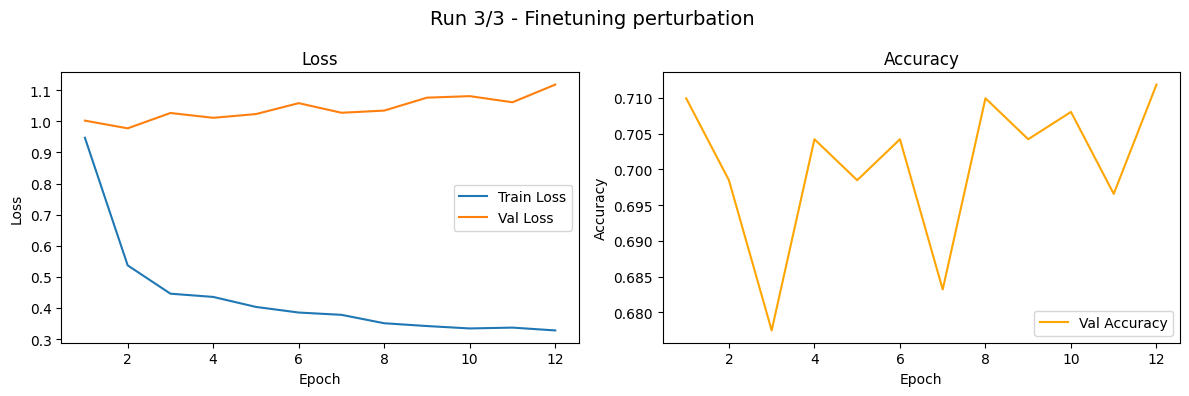

Memory cleaned after run 3


In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

best_lr_head = 0.00030995448268009645

NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    # Load base model fresh each run
    wrapper_model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_images_metadata_1_best_stage2.pt",
        map_location=device,
        weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()

    # only unfreeze the classification head:
    freeze_backbone_3_modalities(wrapper_model)

    wrapper_model.head[-1].reset_parameters()

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_head)

    wrapper_model, history = train_model_3_modalities(
        wrapper_model, train_loader, val_loader, criterion,
        optimizer, device, epochs=50, patience=10,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_perturbation_feature_unlearning_age_head_run{run_idx}.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")

    all_histories[run_idx] = {
        "train_loss": history["train_loss"],
        "val_loss":   history["val_loss"],
        "val_acc":    history["val_acc"],
    }

    # Plot
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Run {run_idx}/{NUM_RUNS} - Finetuning perturbation ", fontsize=14)

    axes[0].plot(epochs_x, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_x, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs_x, history["val_acc"], label="Val Accuracy", color="orange")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Clean up
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")

## (4) Perturbations full body

Using device: cuda

Run 1/3
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 167MB/s]


Epoch [1/50] | Train Loss: 1.8629 | Val Loss: 1.5497 | Val Acc: 0.5802
Best model + history saved
Epoch [2/50] | Train Loss: 1.3086 | Val Loss: 1.3898 | Val Acc: 0.6183
Best model + history saved
Epoch [3/50] | Train Loss: 1.1248 | Val Loss: 1.2307 | Val Acc: 0.6508
Best model + history saved
Epoch [4/50] | Train Loss: 0.9986 | Val Loss: 1.3563 | Val Acc: 0.5821
Epoch [5/50] | Train Loss: 0.8935 | Val Loss: 1.0645 | Val Acc: 0.6775
Best model + history saved
Epoch [6/50] | Train Loss: 0.7930 | Val Loss: 1.0492 | Val Acc: 0.6851
Best model + history saved
Epoch [7/50] | Train Loss: 0.7170 | Val Loss: 1.1746 | Val Acc: 0.6527
Epoch [8/50] | Train Loss: 0.6877 | Val Loss: 1.0300 | Val Acc: 0.6756
Best model + history saved
Epoch [9/50] | Train Loss: 0.6448 | Val Loss: 1.2007 | Val Acc: 0.6145
Epoch [10/50] | Train Loss: 0.6374 | Val Loss: 1.0354 | Val Acc: 0.6718
Epoch [11/50] | Train Loss: 0.5658 | Val Loss: 1.0461 | Val Acc: 0.6927
Epoch [12/50] | Train Loss: 0.5079 | Val Loss: 1.0475 |

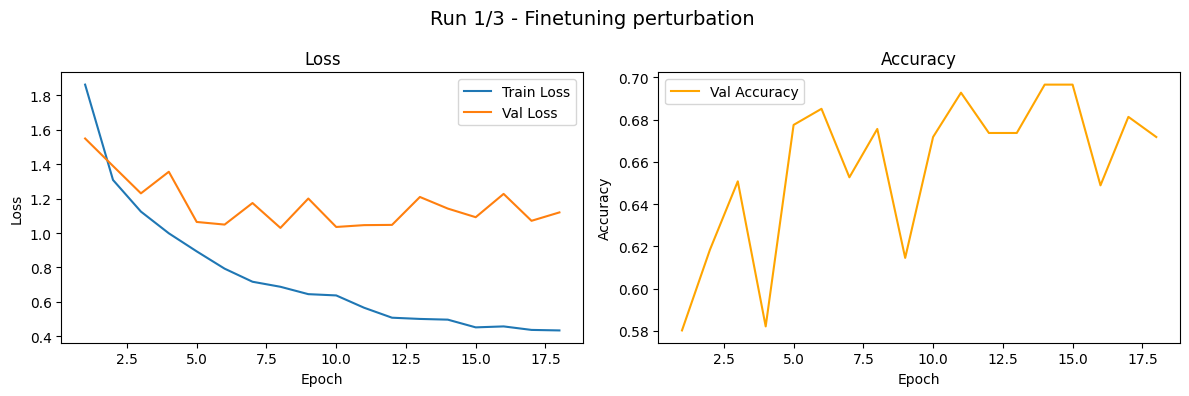

Memory cleaned after run 1

Run 2/3
Epoch [1/50] | Train Loss: 1.6732 | Val Loss: 1.3014 | Val Acc: 0.6756
Best model + history saved
Epoch [2/50] | Train Loss: 1.1398 | Val Loss: 1.2042 | Val Acc: 0.6756
Best model + history saved
Epoch [3/50] | Train Loss: 0.9055 | Val Loss: 1.2170 | Val Acc: 0.6355
Epoch [4/50] | Train Loss: 0.7500 | Val Loss: 1.1910 | Val Acc: 0.6698
Best model + history saved
Epoch [5/50] | Train Loss: 0.6684 | Val Loss: 1.0548 | Val Acc: 0.6775
Best model + history saved
Epoch [6/50] | Train Loss: 0.6001 | Val Loss: 1.0463 | Val Acc: 0.6775
Best model + history saved
Epoch [7/50] | Train Loss: 0.5320 | Val Loss: 1.0828 | Val Acc: 0.6698
Epoch [8/50] | Train Loss: 0.4775 | Val Loss: 1.1040 | Val Acc: 0.6927
Epoch [9/50] | Train Loss: 0.4375 | Val Loss: 1.1248 | Val Acc: 0.6336
Epoch [10/50] | Train Loss: 0.4140 | Val Loss: 1.1499 | Val Acc: 0.6660
Epoch [11/50] | Train Loss: 0.4061 | Val Loss: 1.0828 | Val Acc: 0.6794
Epoch [12/50] | Train Loss: 0.3856 | Val Loss:

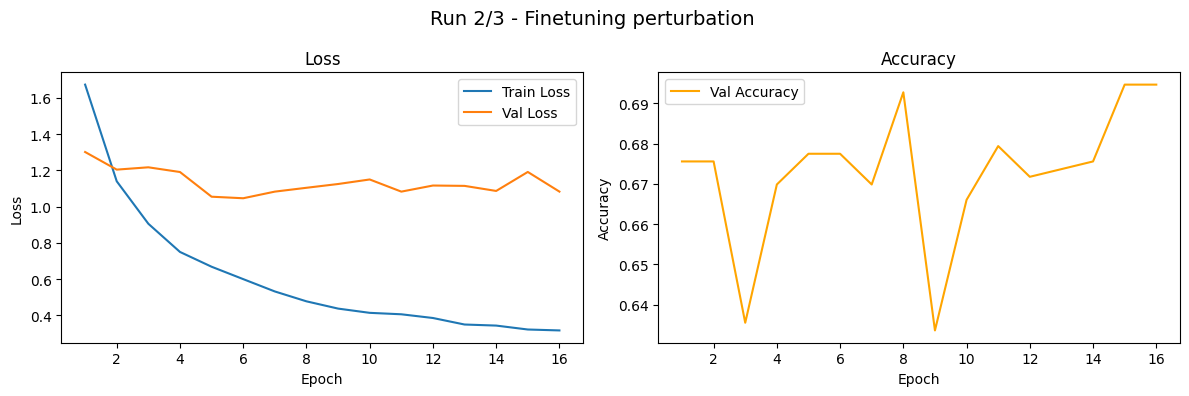

Memory cleaned after run 2

Run 3/3
Epoch [1/50] | Train Loss: 1.6419 | Val Loss: 1.2751 | Val Acc: 0.6603
Best model + history saved
Epoch [2/50] | Train Loss: 1.1144 | Val Loss: 1.1566 | Val Acc: 0.6660
Best model + history saved
Epoch [3/50] | Train Loss: 0.9925 | Val Loss: 1.1866 | Val Acc: 0.6336
Epoch [4/50] | Train Loss: 0.8141 | Val Loss: 1.0788 | Val Acc: 0.6813
Best model + history saved
Epoch [5/50] | Train Loss: 0.6528 | Val Loss: 1.0889 | Val Acc: 0.6832
Epoch [6/50] | Train Loss: 0.5999 | Val Loss: 1.0804 | Val Acc: 0.6794
Epoch [7/50] | Train Loss: 0.5436 | Val Loss: 1.0968 | Val Acc: 0.6737
Epoch [8/50] | Train Loss: 0.4885 | Val Loss: 1.2418 | Val Acc: 0.5840
Epoch [9/50] | Train Loss: 0.4857 | Val Loss: 1.0578 | Val Acc: 0.6985
Best model + history saved
Epoch [10/50] | Train Loss: 0.4340 | Val Loss: 1.0418 | Val Acc: 0.6889
Best model + history saved
Epoch [11/50] | Train Loss: 0.4175 | Val Loss: 1.0557 | Val Acc: 0.6698
Epoch [12/50] | Train Loss: 0.3633 | Val Loss:

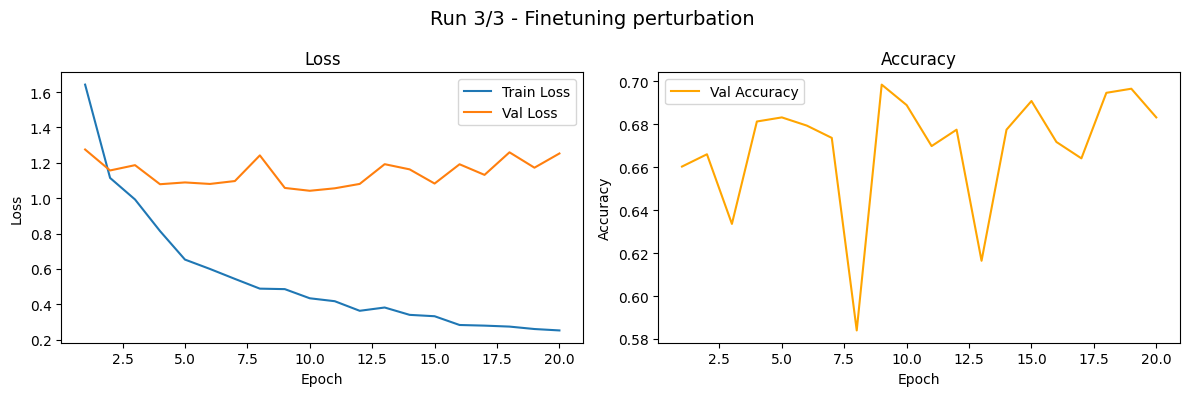

Memory cleaned after run 3


In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

best_lr_full = 5.816190742383745e-05

NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    # Load base model fresh each run
    wrapper_model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_images_metadata_1_best_stage2.pt",
        map_location=device,
        weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()
    unfreeze_all_3_modalities(wrapper_model)
    wrapper_model.head[-1].reset_parameters()

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_full)

    wrapper_model, history = train_model_3_modalities(
        wrapper_model, train_loader, val_loader, criterion,
        optimizer, device, epochs=50, patience=10,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_perturbation_feature_unlearning_age_run{run_idx}.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")

    all_histories[run_idx] = {
        "train_loss": history["train_loss"],
        "val_loss":   history["val_loss"],
        "val_acc":    history["val_acc"],
    }

    # Plot
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Run {run_idx}/{NUM_RUNS} - Finetuning perturbation ", fontsize=14)

    axes[0].plot(epochs_x, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_x, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs_x, history["val_acc"], label="Val Accuracy", color="orange")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Clean up
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")

# Attribute unlearning from the whole dataset

In the following experiment we aim to unlear the age metadata for the whole dataset. This means we will "remove" it by zerouing put all age values in the one-hot encoded vector used to encode it, from both the training set and validation data set.

In literature this is also called attribute unlearning.

THe model architecture will be the proposed Multimodal Cross Attention ViT, using clinical close-up images and full metadata (skin class, age, sex and lession location) since the performance shows a strong dependence on the age metadata column during feature analysis.

Load the data and prepare it

In [7]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "sex", "skin_tone_class", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

df_train_clinical_minimal.head()

,lesion_id,isic_id,image_type,age_approx,sex,skin_tone_class,site,label_id
0,IL_0000652,ISIC_8149219,clinical: close-up,70.0,male,1,head_neck_face,1
1,IL_0003176,ISIC_3904045,clinical: close-up,45.0,female,5,head_neck_face,1
2,IL_0004688,ISIC_0791494,clinical: close-up,50.0,male,3,lower_extremity,1
3,IL_0005081,ISIC_5667730,clinical: close-up,45.0,male,3,head_neck_face,9
4,IL_0006177,ISIC_8803389,clinical: close-up,75.0,male,3,upper_extremity,1


### Prepare map for metadata one-hot encoding so that each value and metadata column have the same order:

In [8]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

if False: # I have already created it and saved it, so shouldn't do it again.
  metadata_maps = build_metadata_maps(df_train_clinical_minimal, metadata_cols)

  # save the metadata maps:
  with open(WORK_DIR_ROOT + "/metadata_maps.json", "w") as f:
    json.dump(metadata_maps, f, indent=2)

# load the maps, because almost certainly I'll have to rerun the whole colab:
with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


### Load the lession_ids for train/val/test stratified datasets

In [9]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# Train
df_train_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)



Lesions - Train: 4191, Val: 524, Test: 525


### Create data loaders with a custom dataset class

For this purpose, use a custom Dataset called Milk10kDataset_multimodal, which receives a dataframe to read the metadata and labels from, a root directory to read the image files from, a custom transform to apply to the images. It assumes only one image type, so we filter beforehand.



### Create the data transformers

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

### Chose metadata column: age

In [11]:
meta_cols = ["age_approx"]

### Create the data loaders

In [13]:
from utils import Milk10kDataset_multimodal_feature_unlearning
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_dataset = Milk10kDataset_multimodal_feature_unlearning(
    df_train_clinical,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=train_transform,
    smoothing=0.1,
    forget_lesion_ids=train_lesions,
    forget_metadata_cols=meta_cols
)

val_dataset = Milk10kDataset_multimodal_feature_unlearning(
    df_val_clinical,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform,
    smoothing=0.1,
    forget_lesion_ids=val_lesions,
    forget_metadata_cols=meta_cols
)

NUM_WORKERS = os.cpu_count()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


Using device: cuda


## (0) Reference model

In [13]:
from VitClassifier_1_defnitions import *
import time
import torch
import gc

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

#STAGE 1: freeze ViT
for param in wrapper_model.vit.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_1_stage1.pt"
)

# cleanup optimizer:
del optimizer_stage1
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_1_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

# cleanup model, optimizers
del wrapper_model, optimizer_stage2, criterion, history_stage1, history_stage2
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

Using device: cuda


ConnectionAbortedError: Caught ConnectionAbortedError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/content/drive/MyDrive/datasets/Master/utils.py", line 189, in __getitem__
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 3513, in open
    fp = builtins.open(filename, "rb")
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ConnectionAbortedError: [Errno 103] Software caused connection abort: '/content/drive/MyDrive/datasets/Master/datasets_resized_stratified/train/IL_2237445/ISIC_5074726.jpg'


Since the garbage collector was not defined, I need to start again stage 2. At least stage 1 is saved.

Using device: cuda
metadata input dimension: 34
Epoch [1/1000] | Train Loss: 0.9201 | Val Loss: 0.9986 | Val Acc: 0.6756
Best model + history saved
Epoch [2/1000] | Train Loss: 0.8466 | Val Loss: 0.9955 | Val Acc: 0.6870
Best model + history saved
Epoch [3/1000] | Train Loss: 0.7984 | Val Loss: 0.9947 | Val Acc: 0.6756
Best model + history saved
Epoch [4/1000] | Train Loss: 0.7443 | Val Loss: 0.9932 | Val Acc: 0.6679
Best model + history saved
Epoch [5/1000] | Train Loss: 0.7059 | Val Loss: 0.9986 | Val Acc: 0.6737
Epoch [6/1000] | Train Loss: 0.6704 | Val Loss: 0.9916 | Val Acc: 0.6737
Best model + history saved
Epoch [7/1000] | Train Loss: 0.6384 | Val Loss: 1.0194 | Val Acc: 0.6565
Epoch [8/1000] | Train Loss: 0.6052 | Val Loss: 1.0056 | Val Acc: 0.6660
Epoch [9/1000] | Train Loss: 0.5610 | Val Loss: 1.0200 | Val Acc: 0.6698
Epoch [10/1000] | Train Loss: 0.5387 | Val Loss: 1.0231 | Val Acc: 0.6870
Epoch [11/1000] | Train Loss: 0.5104 | Val Loss: 1.0362 | Val Acc: 0.6698
Epoch [12/10

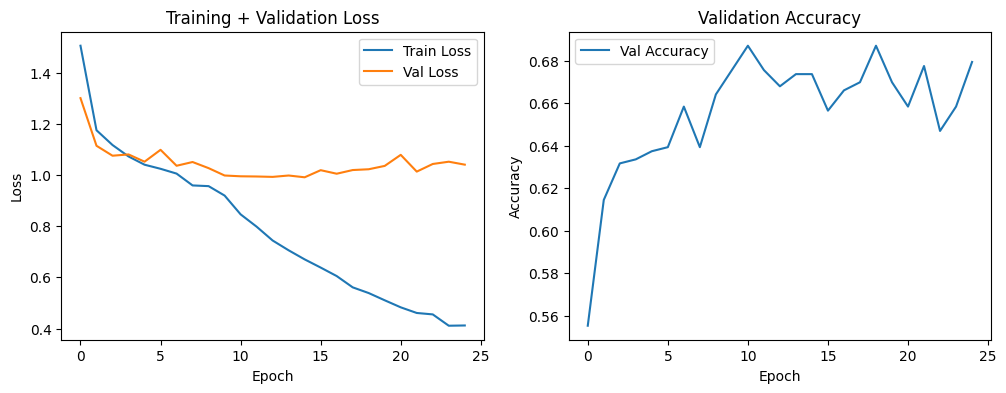

Memory cleaned


In [15]:
from VitClassifier_1_defnitions import *
import time
import torch
import gc

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

checkpoint_path = CHECKPOINT_DIR + "/Reference_attribute_unlearning_age_best_run_1_stage1.pt"

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)

wrapper_model.load_state_dict(checkpoint["model_state"])

history_stage1 = checkpoint["history"]

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_1_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

# cleanup model, optimizers
del wrapper_model, optimizer_stage2, criterion, history_stage1, history_stage2
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

Run 2

Using device: cuda
metadata input dimension: 34
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 192MB/s]


Epoch [1/1000] | Train Loss: 1.5246 | Val Loss: 1.2723 | Val Acc: 0.5973
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1804 | Val Loss: 1.1226 | Val Acc: 0.6088
Best model + history saved
Epoch [3/1000] | Train Loss: 1.1148 | Val Loss: 1.0949 | Val Acc: 0.6202
Best model + history saved
Epoch [4/1000] | Train Loss: 1.0762 | Val Loss: 1.0616 | Val Acc: 0.6298
Best model + history saved
Epoch [5/1000] | Train Loss: 1.0497 | Val Loss: 1.0491 | Val Acc: 0.6260
Best model + history saved
Epoch [6/1000] | Train Loss: 1.0079 | Val Loss: 1.0681 | Val Acc: 0.6279
Epoch [7/1000] | Train Loss: 0.9871 | Val Loss: 1.0260 | Val Acc: 0.6279
Best model + history saved
Epoch [8/1000] | Train Loss: 0.9688 | Val Loss: 1.0335 | Val Acc: 0.6393
Epoch [9/1000] | Train Loss: 0.9466 | Val Loss: 1.0162 | Val Acc: 0.6584
Best model + history saved
Epoch [10/1000] | Train Loss: 0.9304 | Val Loss: 1.0128 | Val Acc: 0.6393
Best model + history saved
Epoch [11/1000] | Train Loss: 0.9120 | Val Loss: 1.05

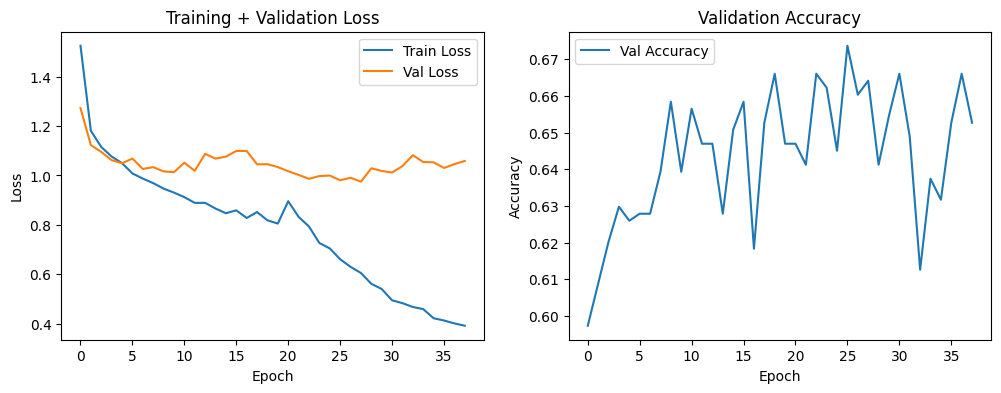

Memory cleaned


In [13]:
from VitClassifier_1_defnitions import *
import time
import torch
import gc

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# STAGE 1: freeze ViT
for param in wrapper_model.vit.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_2_stage1.pt"
)

# cleanup optimizer:
del optimizer_stage1
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_2_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

# cleanup model, optimizers
del wrapper_model, optimizer_stage2, criterion, history_stage1, history_stage2
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

Run 3

Using device: cuda
metadata input dimension: 34
Epoch [1/1000] | Train Loss: 1.5409 | Val Loss: 1.2165 | Val Acc: 0.5782
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1661 | Val Loss: 1.1423 | Val Acc: 0.6183
Best model + history saved
Epoch [3/1000] | Train Loss: 1.1159 | Val Loss: 1.0764 | Val Acc: 0.6221
Best model + history saved
Epoch [4/1000] | Train Loss: 1.0828 | Val Loss: 1.0777 | Val Acc: 0.6279
Epoch [5/1000] | Train Loss: 1.0430 | Val Loss: 1.0755 | Val Acc: 0.6412
Best model + history saved
Epoch [6/1000] | Train Loss: 1.0239 | Val Loss: 1.0829 | Val Acc: 0.6355
Epoch [7/1000] | Train Loss: 0.9940 | Val Loss: 1.0431 | Val Acc: 0.6317
Best model + history saved
Epoch [8/1000] | Train Loss: 0.9667 | Val Loss: 1.0488 | Val Acc: 0.6374
Epoch [9/1000] | Train Loss: 0.9481 | Val Loss: 1.0645 | Val Acc: 0.6527
Epoch [10/1000] | Train Loss: 0.9323 | Val Loss: 1.0443 | Val Acc: 0.6584
Epoch [11/1000] | Train Loss: 0.9131 | Val Loss: 1.0846 | Val Acc: 0.6317
Epoch [12/10

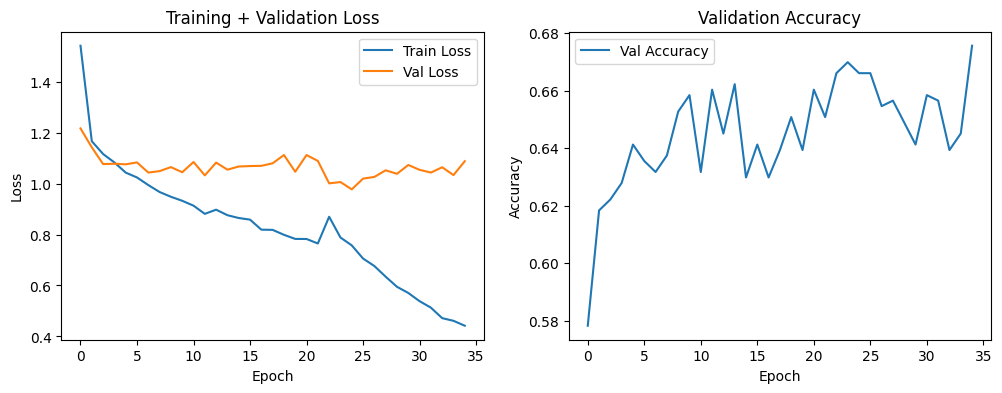

Memory cleaned


In [14]:
from VitClassifier_1_defnitions import *
import time
import torch
import gc

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# STAGE 1: freeze ViT
for param in wrapper_model.vit.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_3_stage1.pt"
)

# cleanup optimizer:
del optimizer_stage1
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_3_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

# cleanup model, optimizers
del wrapper_model, optimizer_stage2, criterion, history_stage1, history_stage2
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

## (1) Fine-tuning with perturbations Head only

Using device: cuda

Run 1/3
Epoch [1/50] | Train Loss: 1.1369 | Val Loss: 1.0856 | Val Acc: 0.6527
Best model + history saved
Epoch [2/50] | Train Loss: 0.8669 | Val Loss: 1.0533 | Val Acc: 0.6584
Best model + history saved
Epoch [3/50] | Train Loss: 0.7931 | Val Loss: 1.0556 | Val Acc: 0.6603
Epoch [4/50] | Train Loss: 0.7754 | Val Loss: 1.0293 | Val Acc: 0.6641
Best model + history saved
Epoch [5/50] | Train Loss: 0.7493 | Val Loss: 1.0759 | Val Acc: 0.6622
Epoch [6/50] | Train Loss: 0.7280 | Val Loss: 1.0700 | Val Acc: 0.6431
Epoch [7/50] | Train Loss: 0.7265 | Val Loss: 1.1286 | Val Acc: 0.6546
Epoch [8/50] | Train Loss: 0.6971 | Val Loss: 1.1012 | Val Acc: 0.6565
Epoch [9/50] | Train Loss: 0.6948 | Val Loss: 1.2118 | Val Acc: 0.6412
Epoch [10/50] | Train Loss: 0.6670 | Val Loss: 1.1605 | Val Acc: 0.6450
Epoch [11/50] | Train Loss: 0.6613 | Val Loss: 1.1037 | Val Acc: 0.6718
Epoch [12/50] | Train Loss: 0.6394 | Val Loss: 1.1053 | Val Acc: 0.6832
Epoch [13/50] | Train Loss: 0.6440 |

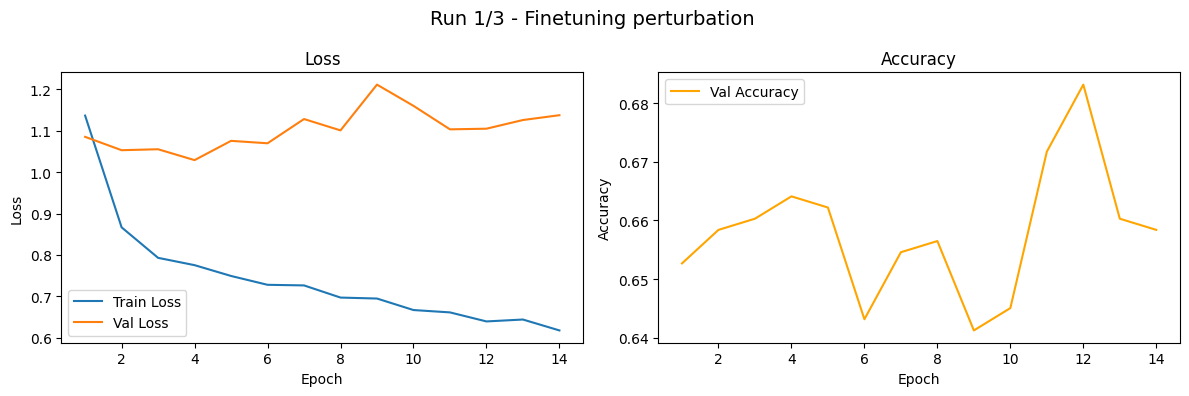

Memory cleaned after run 1

Run 2/3
Epoch [1/50] | Train Loss: 1.1148 | Val Loss: 1.1156 | Val Acc: 0.6317
Best model + history saved
Epoch [2/50] | Train Loss: 0.8723 | Val Loss: 1.0944 | Val Acc: 0.6279
Best model + history saved
Epoch [3/50] | Train Loss: 0.7990 | Val Loss: 1.1541 | Val Acc: 0.6317
Epoch [4/50] | Train Loss: 0.7844 | Val Loss: 1.0975 | Val Acc: 0.6603
Epoch [5/50] | Train Loss: 0.7205 | Val Loss: 1.1156 | Val Acc: 0.6469
Epoch [6/50] | Train Loss: 0.7159 | Val Loss: 1.1689 | Val Acc: 0.6355
Epoch [7/50] | Train Loss: 0.7041 | Val Loss: 1.1156 | Val Acc: 0.6431
Epoch [8/50] | Train Loss: 0.6982 | Val Loss: 1.1319 | Val Acc: 0.6374
Epoch [9/50] | Train Loss: 0.6836 | Val Loss: 1.1048 | Val Acc: 0.6469
Epoch [10/50] | Train Loss: 0.6476 | Val Loss: 1.1811 | Val Acc: 0.6450
Epoch [11/50] | Train Loss: 0.6608 | Val Loss: 1.1980 | Val Acc: 0.6374
Epoch [12/50] | Train Loss: 0.6326 | Val Loss: 1.1784 | Val Acc: 0.6145
Early stopping triggered

Run 2 finished in 13.83 minut

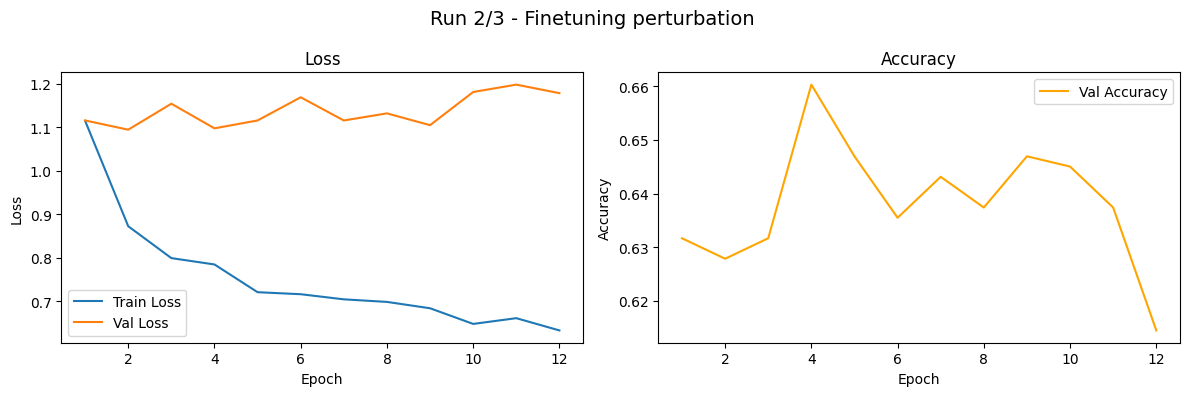

Memory cleaned after run 2

Run 3/3
Epoch [1/50] | Train Loss: 1.1759 | Val Loss: 1.1053 | Val Acc: 0.6393
Best model + history saved
Epoch [2/50] | Train Loss: 0.8622 | Val Loss: 1.1059 | Val Acc: 0.6260
Epoch [3/50] | Train Loss: 0.8252 | Val Loss: 1.0402 | Val Acc: 0.6469
Best model + history saved
Epoch [4/50] | Train Loss: 0.7718 | Val Loss: 1.0972 | Val Acc: 0.6260
Epoch [5/50] | Train Loss: 0.7601 | Val Loss: 1.0816 | Val Acc: 0.6565
Epoch [6/50] | Train Loss: 0.7238 | Val Loss: 1.1078 | Val Acc: 0.6469
Epoch [7/50] | Train Loss: 0.7135 | Val Loss: 1.1397 | Val Acc: 0.6718
Epoch [8/50] | Train Loss: 0.6923 | Val Loss: 1.1022 | Val Acc: 0.6374
Epoch [9/50] | Train Loss: 0.7000 | Val Loss: 1.1020 | Val Acc: 0.6641
Epoch [10/50] | Train Loss: 0.6546 | Val Loss: 1.1650 | Val Acc: 0.6660
Epoch [11/50] | Train Loss: 0.6551 | Val Loss: 1.1274 | Val Acc: 0.6317
Epoch [12/50] | Train Loss: 0.6502 | Val Loss: 1.1086 | Val Acc: 0.6355
Epoch [13/50] | Train Loss: 0.6404 | Val Loss: 1.1115 |

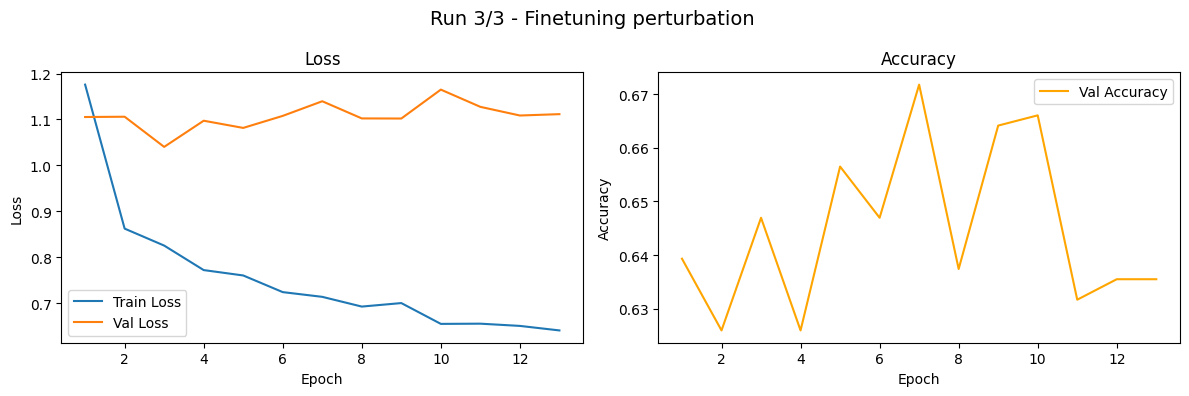

Memory cleaned after run 3


In [16]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

best_lr_head = 0.0004615619914925977

NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    # Load base model fresh each run
    wrapper_model = CrossAttentionModel(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_1_multimodal_best_stage2.pt",
        map_location=device,
        weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()

    # only unfreeze the classification head:
    for param in wrapper_model.vit.parameters():
        param.requires_grad = False

    wrapper_model.head[-1].reset_parameters()

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_head)

    wrapper_model, history = train_model_multimodal(
        wrapper_model, train_loader, val_loader, criterion,
        optimizer, device, epochs=50, patience=10,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_perturbation_attribute_unlearning_age_head_run{run_idx}.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")

    all_histories[run_idx] = {
        "train_loss": history["train_loss"],
        "val_loss":   history["val_loss"],
        "val_acc":    history["val_acc"],
    }

    # Plot
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Run {run_idx}/{NUM_RUNS} - Finetuning perturbation ", fontsize=14)

    axes[0].plot(epochs_x, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_x, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs_x, history["val_acc"], label="Val Accuracy", color="orange")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Clean up
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")

## (2) Fine-tuning with perturbations full body

Using device: cuda

Run 1/3
Epoch [1/50] | Train Loss: 2.0964 | Val Loss: 1.8425 | Val Acc: 0.5344
Best model + history saved
Epoch [2/50] | Train Loss: 1.7780 | Val Loss: 1.6808 | Val Acc: 0.5840
Best model + history saved
Epoch [3/50] | Train Loss: 1.5809 | Val Loss: 1.5398 | Val Acc: 0.6107
Best model + history saved
Epoch [4/50] | Train Loss: 1.4463 | Val Loss: 1.4985 | Val Acc: 0.6050
Best model + history saved
Epoch [5/50] | Train Loss: 1.3066 | Val Loss: 1.3828 | Val Acc: 0.6431
Best model + history saved
Epoch [6/50] | Train Loss: 1.2256 | Val Loss: 1.3492 | Val Acc: 0.6317
Best model + history saved
Epoch [7/50] | Train Loss: 1.1068 | Val Loss: 1.2998 | Val Acc: 0.6469
Best model + history saved
Epoch [8/50] | Train Loss: 1.0775 | Val Loss: 1.2778 | Val Acc: 0.6374
Best model + history saved
Epoch [9/50] | Train Loss: 0.9859 | Val Loss: 1.2689 | Val Acc: 0.6355
Best model + history saved
Epoch [10/50] | Train Loss: 0.9216 | Val Loss: 1.2474 | Val Acc: 0.6336
Best model + histo

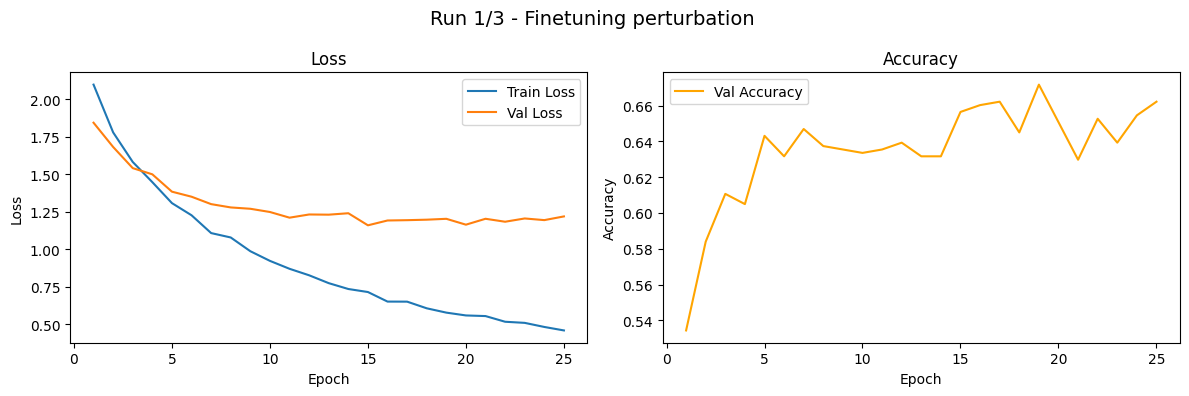

Memory cleaned after run 1

Run 2/3
Epoch [1/50] | Train Loss: 2.4921 | Val Loss: 2.1620 | Val Acc: 0.3931
Best model + history saved
Epoch [2/50] | Train Loss: 2.1174 | Val Loss: 1.8967 | Val Acc: 0.5802
Best model + history saved
Epoch [3/50] | Train Loss: 1.8759 | Val Loss: 1.7714 | Val Acc: 0.5916
Best model + history saved
Epoch [4/50] | Train Loss: 1.6915 | Val Loss: 1.6100 | Val Acc: 0.6145
Best model + history saved
Epoch [5/50] | Train Loss: 1.5616 | Val Loss: 1.5899 | Val Acc: 0.6031
Best model + history saved
Epoch [6/50] | Train Loss: 1.4711 | Val Loss: 1.5561 | Val Acc: 0.6050
Best model + history saved
Epoch [7/50] | Train Loss: 1.3693 | Val Loss: 1.5081 | Val Acc: 0.5954
Best model + history saved
Epoch [8/50] | Train Loss: 1.3085 | Val Loss: 1.3999 | Val Acc: 0.6393
Best model + history saved
Epoch [9/50] | Train Loss: 1.2500 | Val Loss: 1.3229 | Val Acc: 0.6317
Best model + history saved
Epoch [10/50] | Train Loss: 1.1783 | Val Loss: 1.2998 | Val Acc: 0.6412
Best model

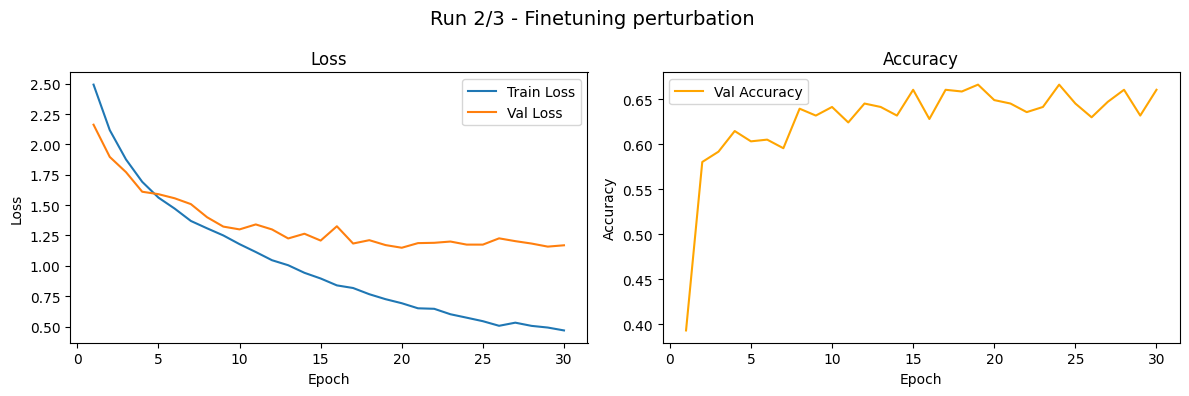

Memory cleaned after run 2

Run 3/3
Epoch [1/50] | Train Loss: 2.4571 | Val Loss: 2.1906 | Val Acc: 0.2042
Best model + history saved
Epoch [2/50] | Train Loss: 2.0617 | Val Loss: 1.9218 | Val Acc: 0.5725
Best model + history saved
Epoch [3/50] | Train Loss: 1.8408 | Val Loss: 1.7548 | Val Acc: 0.6126
Best model + history saved
Epoch [4/50] | Train Loss: 1.6450 | Val Loss: 1.5375 | Val Acc: 0.6126
Best model + history saved
Epoch [5/50] | Train Loss: 1.4974 | Val Loss: 1.4793 | Val Acc: 0.6279
Best model + history saved
Epoch [6/50] | Train Loss: 1.3825 | Val Loss: 1.5776 | Val Acc: 0.6011
Epoch [7/50] | Train Loss: 1.2897 | Val Loss: 1.3945 | Val Acc: 0.6355
Best model + history saved
Epoch [8/50] | Train Loss: 1.2157 | Val Loss: 1.4130 | Val Acc: 0.6279
Epoch [9/50] | Train Loss: 1.1395 | Val Loss: 1.3039 | Val Acc: 0.6317
Best model + history saved
Epoch [10/50] | Train Loss: 1.0722 | Val Loss: 1.2906 | Val Acc: 0.6412
Best model + history saved
Epoch [11/50] | Train Loss: 1.0139 | 

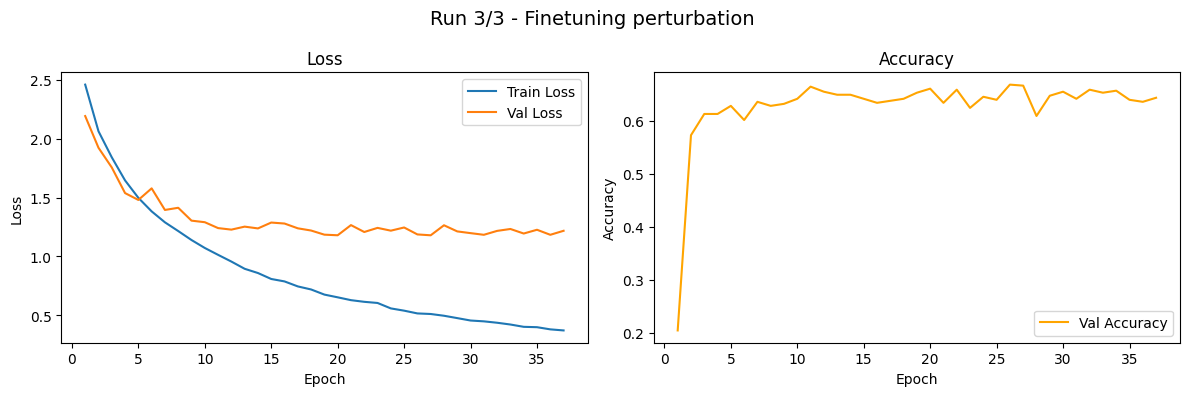

Memory cleaned after run 3


In [17]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

best_lr_full = 1.1526026851977796e-05

NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    # Load base model fresh each run
    wrapper_model = CrossAttentionModel(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_1_multimodal_best_stage2.pt",
        map_location=device,
        weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()

    # unfreeze all layers:
    for param in wrapper_model.vit.parameters():
        param.requires_grad = True

    wrapper_model.head[-1].reset_parameters()

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_full)

    wrapper_model, history = train_model_multimodal(
        wrapper_model, train_loader, val_loader, criterion,
        optimizer, device, epochs=50, patience=10,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_perturbation_attribute_unlearning_age_full_run{run_idx}.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")

    all_histories[run_idx] = {
        "train_loss": history["train_loss"],
        "val_loss":   history["val_loss"],
        "val_acc":    history["val_acc"],
    }

    # Plot
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Run {run_idx}/{NUM_RUNS} - Finetuning perturbation ", fontsize=14)

    axes[0].plot(epochs_x, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_x, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs_x, history["val_acc"], label="Val Accuracy", color="orange")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Clean up
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")

## (3) Fine-tuning 4 epochs

Using device: cuda

Run 1/3
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 121MB/s] 


Epoch [1/4] | Train Loss: 0.7728 | Val Loss: 1.0169 | Val Acc: 0.6622
Best model + history saved
Epoch [2/4] | Train Loss: 0.7292 | Val Loss: 0.9938 | Val Acc: 0.6698
Best model + history saved
Epoch [3/4] | Train Loss: 0.6687 | Val Loss: 1.0544 | Val Acc: 0.6412
Epoch [4/4] | Train Loss: 0.6385 | Val Loss: 0.9926 | Val Acc: 0.6794
Best model + history saved
Final epoch model saved

Run 1 finished in 41.92 minutes


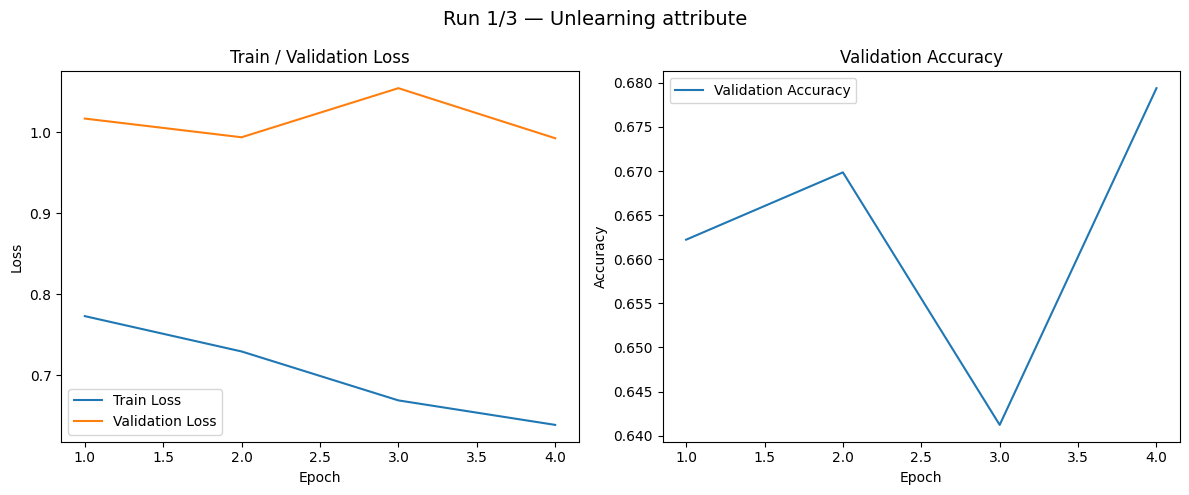

Memory cleaned after run 1

Run 2/3
Epoch [1/4] | Train Loss: 0.7792 | Val Loss: 1.0028 | Val Acc: 0.6641
Best model + history saved
Epoch [2/4] | Train Loss: 0.7028 | Val Loss: 1.0130 | Val Acc: 0.6546
Epoch [3/4] | Train Loss: 0.6763 | Val Loss: 1.0191 | Val Acc: 0.6279
Epoch [4/4] | Train Loss: 0.6111 | Val Loss: 1.0139 | Val Acc: 0.6641
Final epoch model saved

Run 2 finished in 10.58 minutes


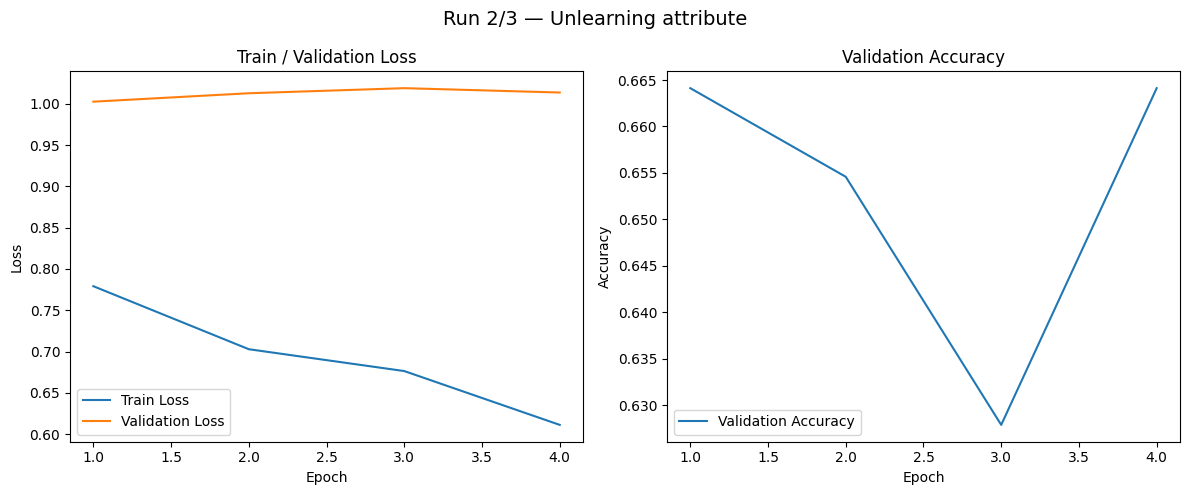

Memory cleaned after run 2

Run 3/3
Epoch [1/4] | Train Loss: 0.7747 | Val Loss: 1.0028 | Val Acc: 0.6660
Best model + history saved
Epoch [2/4] | Train Loss: 0.7081 | Val Loss: 1.0006 | Val Acc: 0.6737
Best model + history saved
Epoch [3/4] | Train Loss: 0.6691 | Val Loss: 1.0113 | Val Acc: 0.6508
Epoch [4/4] | Train Loss: 0.6189 | Val Loss: 1.0245 | Val Acc: 0.6718
Final epoch model saved

Run 3 finished in 10.94 minutes


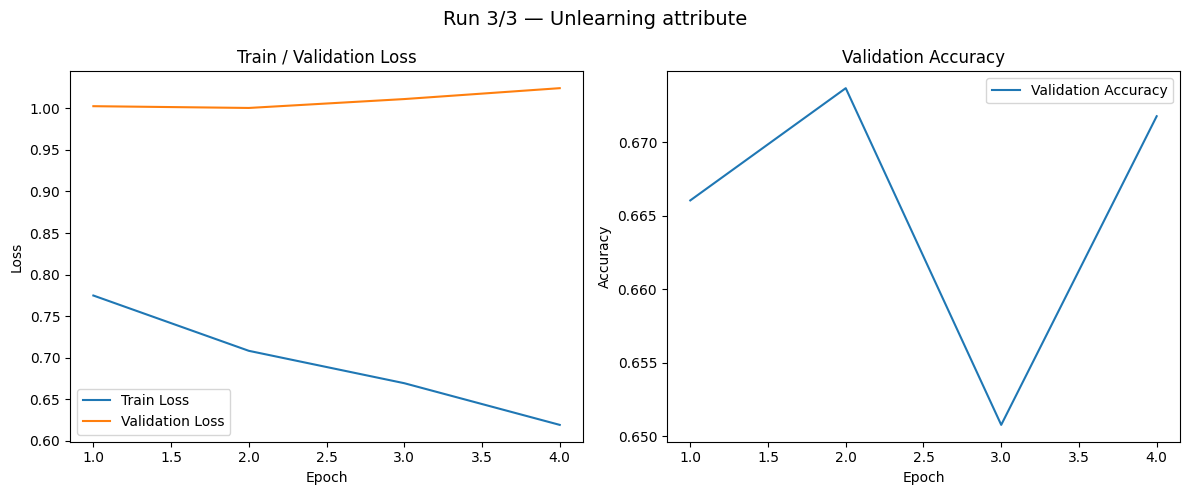

Memory cleaned after run 3


In [14]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

SAVE_EPOCH = 4
best_lr_full = 1.1526026851977796e-05


NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    wrapper_model = CrossAttentionModel(
        metadata_dim=train_dataset.metadata_dim, num_classes=11
    ).to(device)
    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_1_multimodal_best_stage2.pt",
        map_location=device, weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()
     # unfreeze all layers:
    for param in wrapper_model.vit.parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_full)


    wrapper_model, history = train_model_multimodal(
        model=wrapper_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=SAVE_EPOCH,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_attribute_unlearning_age_4_epochs_run{run_idx}_2.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")


    # --- Plot immediately ---
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
       f"Run {run_idx}/{NUM_RUNS} — Unlearning attribute",
       fontsize=14
    )

    # Loss plot

    axes[0].plot(
       epochs_x,
       history["train_loss"],
       label="Train Loss"
    )

    axes[0].plot(
      epochs_x,
      history["val_loss"],
      label="Validation Loss"
    )

    axes[0].set_title("Train / Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # -----------------------------
    # Accuracy plot
    # -----------------------------

    axes[1].plot(
        epochs_x,
        history["val_acc"],
        label="Validation Accuracy"
    )

    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Clean up ---
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")

# Attribute unlearning

In the following experiment we aim to unlear the age metadata for the whole dataset. This means we will "remove" it by zerouing put all age values in the one-hot encoded vector used to encode it, from both the training set and validation data set.

In literature this is also called attribute unlearning.

THe model architecture will be the proposed Multimodal Cross Attention ViT, using clinical close-up images and full metadata (skin class, age, sex and lession location) since the performance shows a strong dependence on the age metadata column during feature analysis.

Load the data and prepare it

In [7]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "sex", "skin_tone_class", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

df_train_clinical_minimal.head()

,lesion_id,isic_id,image_type,age_approx,sex,skin_tone_class,site,label_id
0,IL_0000652,ISIC_8149219,clinical: close-up,70.0,male,1,head_neck_face,1
1,IL_0003176,ISIC_3904045,clinical: close-up,45.0,female,5,head_neck_face,1
2,IL_0004688,ISIC_0791494,clinical: close-up,50.0,male,3,lower_extremity,1
3,IL_0005081,ISIC_5667730,clinical: close-up,45.0,male,3,head_neck_face,9
4,IL_0006177,ISIC_8803389,clinical: close-up,75.0,male,3,upper_extremity,1


### Prepare map for metadata one-hot encoding so that each value and metadata column have the same order:

In [8]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

if False: # I have already created it and saved it, so shouldn't do it again.
  metadata_maps = build_metadata_maps(df_train_clinical_minimal, metadata_cols)

  # save the metadata maps:
  with open(WORK_DIR_ROOT + "/metadata_maps.json", "w") as f:
    json.dump(metadata_maps, f, indent=2)

# load the maps, because almost certainly I'll have to rerun the whole colab:
with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


### Load the lession_ids for train/val/test stratified datasets

In [9]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# Train
df_train_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)



Lesions - Train: 4191, Val: 524, Test: 525


### Create data loaders with a custom dataset class

For this purpose, use a custom Dataset called Milk10kDataset_multimodal, which receives a dataframe to read the metadata and labels from, a root directory to read the image files from, a custom transform to apply to the images. It assumes only one image type, so we filter beforehand.



### Create the data transformers

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

### Chose metadata column: age

In [11]:
meta_cols = ["age_approx"]

### Create the data loaders

In [12]:
from utils import Milk10kDataset_multimodal_feature_unlearning
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_dataset = Milk10kDataset_multimodal_feature_unlearning(
    df_train_clinical,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=train_transform,
    smoothing=0.1,
    forget_lesion_ids=train_lesions,
    forget_metadata_cols=meta_cols
)

val_dataset = Milk10kDataset_multimodal_feature_unlearning(
    df_val_clinical,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform,
    smoothing=0.1,
    forget_lesion_ids=val_lesions,
    forget_metadata_cols=meta_cols
)

NUM_WORKERS = os.cpu_count()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


Using device: cuda


## (0) Reference model

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch
import gc

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

#STAGE 1: freeze ViT
for param in wrapper_model.vit.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_1_stage1.pt"
)

# cleanup optimizer:
del optimizer_stage1
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_1_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

# cleanup model, optimizers
del wrapper_model, optimizer_stage2, criterion, history_stage1, history_stage2
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

Using device: cuda


ConnectionAbortedError: Caught ConnectionAbortedError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/content/drive/MyDrive/datasets/Master/utils.py", line 189, in __getitem__
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 3513, in open
    fp = builtins.open(filename, "rb")
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ConnectionAbortedError: [Errno 103] Software caused connection abort: '/content/drive/MyDrive/datasets/Master/datasets_resized_stratified/train/IL_2237445/ISIC_5074726.jpg'


Since the garbage collector was not defined, I need to start again stage 2. At least stage 1 is saved.

Using device: cuda
metadata input dimension: 34
Epoch [1/1000] | Train Loss: 0.9201 | Val Loss: 0.9986 | Val Acc: 0.6756
Best model + history saved
Epoch [2/1000] | Train Loss: 0.8466 | Val Loss: 0.9955 | Val Acc: 0.6870
Best model + history saved
Epoch [3/1000] | Train Loss: 0.7984 | Val Loss: 0.9947 | Val Acc: 0.6756
Best model + history saved
Epoch [4/1000] | Train Loss: 0.7443 | Val Loss: 0.9932 | Val Acc: 0.6679
Best model + history saved
Epoch [5/1000] | Train Loss: 0.7059 | Val Loss: 0.9986 | Val Acc: 0.6737
Epoch [6/1000] | Train Loss: 0.6704 | Val Loss: 0.9916 | Val Acc: 0.6737
Best model + history saved
Epoch [7/1000] | Train Loss: 0.6384 | Val Loss: 1.0194 | Val Acc: 0.6565
Epoch [8/1000] | Train Loss: 0.6052 | Val Loss: 1.0056 | Val Acc: 0.6660
Epoch [9/1000] | Train Loss: 0.5610 | Val Loss: 1.0200 | Val Acc: 0.6698
Epoch [10/1000] | Train Loss: 0.5387 | Val Loss: 1.0231 | Val Acc: 0.6870
Epoch [11/1000] | Train Loss: 0.5104 | Val Loss: 1.0362 | Val Acc: 0.6698
Epoch [12/10

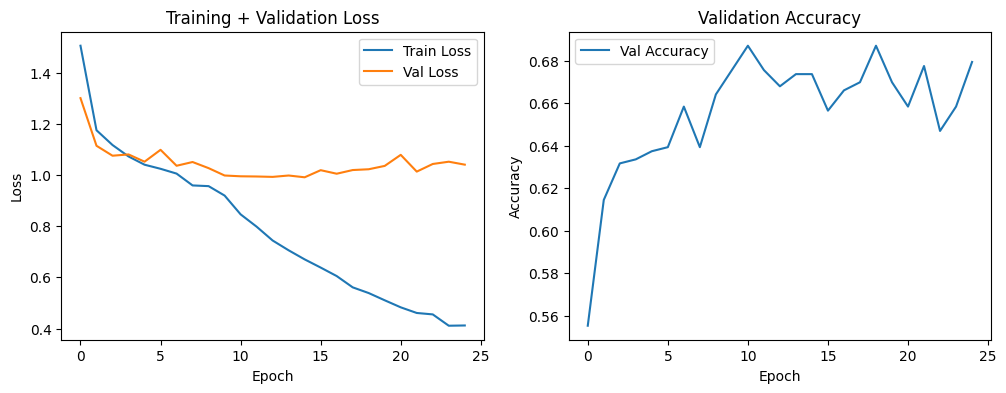

Memory cleaned


In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch
import gc

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

checkpoint_path = CHECKPOINT_DIR + "/Reference_attribute_unlearning_age_best_run_1_stage1.pt"

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)

wrapper_model.load_state_dict(checkpoint["model_state"])

history_stage1 = checkpoint["history"]

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_1_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

# cleanup model, optimizers
del wrapper_model, optimizer_stage2, criterion, history_stage1, history_stage2
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

Run 2

Using device: cuda
metadata input dimension: 34
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 192MB/s]


Epoch [1/1000] | Train Loss: 1.5246 | Val Loss: 1.2723 | Val Acc: 0.5973
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1804 | Val Loss: 1.1226 | Val Acc: 0.6088
Best model + history saved
Epoch [3/1000] | Train Loss: 1.1148 | Val Loss: 1.0949 | Val Acc: 0.6202
Best model + history saved
Epoch [4/1000] | Train Loss: 1.0762 | Val Loss: 1.0616 | Val Acc: 0.6298
Best model + history saved
Epoch [5/1000] | Train Loss: 1.0497 | Val Loss: 1.0491 | Val Acc: 0.6260
Best model + history saved
Epoch [6/1000] | Train Loss: 1.0079 | Val Loss: 1.0681 | Val Acc: 0.6279
Epoch [7/1000] | Train Loss: 0.9871 | Val Loss: 1.0260 | Val Acc: 0.6279
Best model + history saved
Epoch [8/1000] | Train Loss: 0.9688 | Val Loss: 1.0335 | Val Acc: 0.6393
Epoch [9/1000] | Train Loss: 0.9466 | Val Loss: 1.0162 | Val Acc: 0.6584
Best model + history saved
Epoch [10/1000] | Train Loss: 0.9304 | Val Loss: 1.0128 | Val Acc: 0.6393
Best model + history saved
Epoch [11/1000] | Train Loss: 0.9120 | Val Loss: 1.05

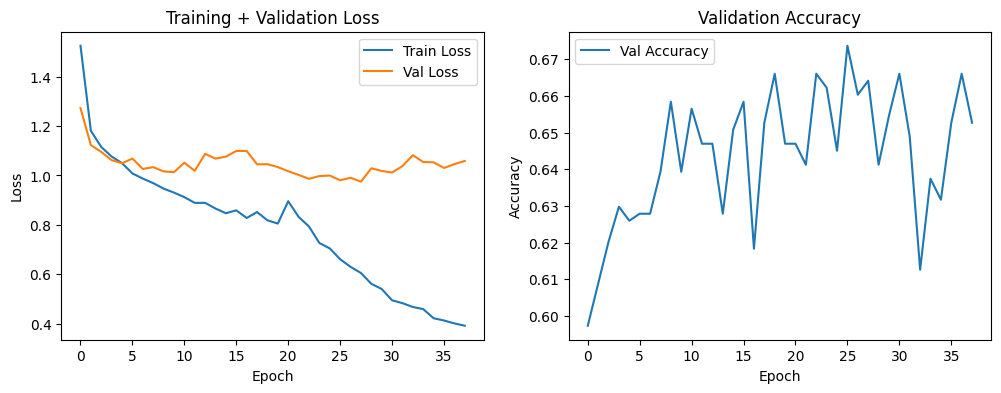

Memory cleaned


In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch
import gc

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# STAGE 1: freeze ViT
for param in wrapper_model.vit.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_2_stage1.pt"
)

# cleanup optimizer:
del optimizer_stage1
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_2_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

# cleanup model, optimizers
del wrapper_model, optimizer_stage2, criterion, history_stage1, history_stage2
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

Run 3

Using device: cuda
metadata input dimension: 34
Epoch [1/1000] | Train Loss: 1.5409 | Val Loss: 1.2165 | Val Acc: 0.5782
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1661 | Val Loss: 1.1423 | Val Acc: 0.6183
Best model + history saved
Epoch [3/1000] | Train Loss: 1.1159 | Val Loss: 1.0764 | Val Acc: 0.6221
Best model + history saved
Epoch [4/1000] | Train Loss: 1.0828 | Val Loss: 1.0777 | Val Acc: 0.6279
Epoch [5/1000] | Train Loss: 1.0430 | Val Loss: 1.0755 | Val Acc: 0.6412
Best model + history saved
Epoch [6/1000] | Train Loss: 1.0239 | Val Loss: 1.0829 | Val Acc: 0.6355
Epoch [7/1000] | Train Loss: 0.9940 | Val Loss: 1.0431 | Val Acc: 0.6317
Best model + history saved
Epoch [8/1000] | Train Loss: 0.9667 | Val Loss: 1.0488 | Val Acc: 0.6374
Epoch [9/1000] | Train Loss: 0.9481 | Val Loss: 1.0645 | Val Acc: 0.6527
Epoch [10/1000] | Train Loss: 0.9323 | Val Loss: 1.0443 | Val Acc: 0.6584
Epoch [11/1000] | Train Loss: 0.9131 | Val Loss: 1.0846 | Val Acc: 0.6317
Epoch [12/10

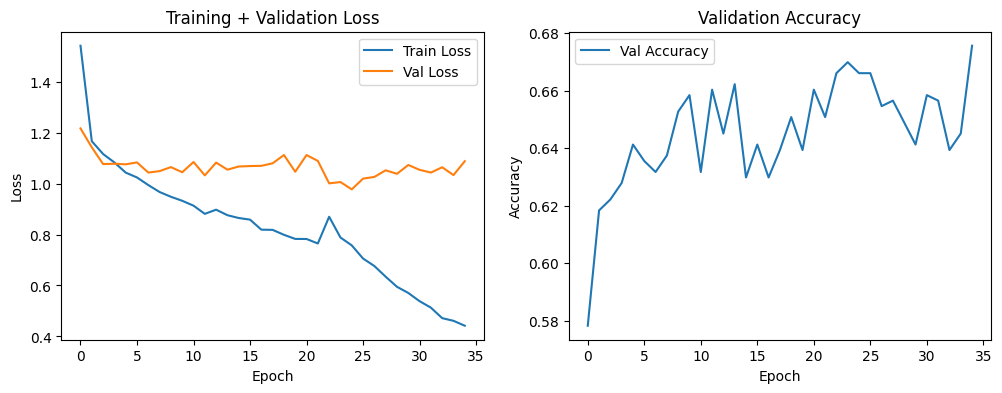

Memory cleaned


In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch
import gc

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# STAGE 1: freeze ViT
for param in wrapper_model.vit.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_3_stage1.pt"
)

# cleanup optimizer:
del optimizer_stage1
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Reference_attribute_unlearning_age_best_run_3_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

# cleanup model, optimizers
del wrapper_model, optimizer_stage2, criterion, history_stage1, history_stage2
torch.cuda.empty_cache()
gc.collect()
print("Memory cleaned")

## (1) Fine-tuning with perturbations Head only

Using device: cuda

Run 1/3
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 159MB/s]


Epoch [1/50] | Train Loss: 1.1111 | Val Loss: 1.1181 | Val Acc: 0.6469
Best model + history saved
Epoch [2/50] | Train Loss: 0.7389 | Val Loss: 1.1297 | Val Acc: 0.6145
Epoch [3/50] | Train Loss: 0.6825 | Val Loss: 1.1027 | Val Acc: 0.6489
Best model + history saved
Epoch [4/50] | Train Loss: 0.6637 | Val Loss: 1.1292 | Val Acc: 0.6489
Epoch [5/50] | Train Loss: 0.6285 | Val Loss: 1.1776 | Val Acc: 0.6603
Epoch [6/50] | Train Loss: 0.6100 | Val Loss: 1.1817 | Val Acc: 0.6718
Epoch [7/50] | Train Loss: 0.5905 | Val Loss: 1.1942 | Val Acc: 0.6546
Epoch [8/50] | Train Loss: 0.5876 | Val Loss: 1.1689 | Val Acc: 0.6431
Epoch [9/50] | Train Loss: 0.5810 | Val Loss: 1.2416 | Val Acc: 0.6260
Epoch [10/50] | Train Loss: 0.5586 | Val Loss: 1.2716 | Val Acc: 0.6546
Epoch [11/50] | Train Loss: 0.5548 | Val Loss: 1.3107 | Val Acc: 0.6508
Epoch [12/50] | Train Loss: 0.5172 | Val Loss: 1.2190 | Val Acc: 0.6489
Epoch [13/50] | Train Loss: 0.5329 | Val Loss: 1.2595 | Val Acc: 0.6546
Early stopping trig

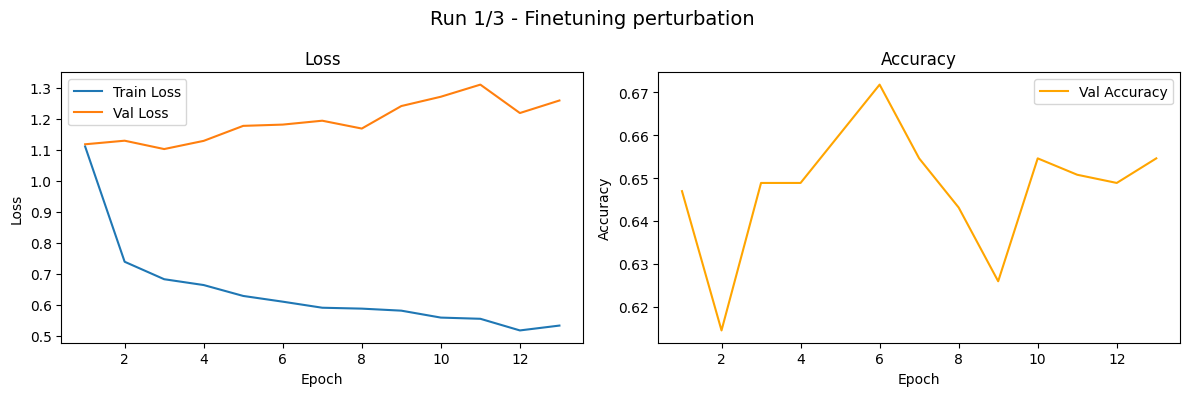

Memory cleaned after run 1

Run 2/3
Epoch [1/50] | Train Loss: 1.0426 | Val Loss: 1.1355 | Val Acc: 0.6145
Best model + history saved
Epoch [2/50] | Train Loss: 0.7200 | Val Loss: 1.0958 | Val Acc: 0.6412
Best model + history saved
Epoch [3/50] | Train Loss: 0.6814 | Val Loss: 1.0913 | Val Acc: 0.6603
Best model + history saved
Epoch [4/50] | Train Loss: 0.6365 | Val Loss: 1.1953 | Val Acc: 0.6508
Epoch [5/50] | Train Loss: 0.6202 | Val Loss: 1.1080 | Val Acc: 0.6603
Epoch [6/50] | Train Loss: 0.6163 | Val Loss: 1.1693 | Val Acc: 0.6298
Epoch [7/50] | Train Loss: 0.5691 | Val Loss: 1.2093 | Val Acc: 0.6164
Epoch [8/50] | Train Loss: 0.5681 | Val Loss: 1.1598 | Val Acc: 0.6698
Epoch [9/50] | Train Loss: 0.5614 | Val Loss: 1.2519 | Val Acc: 0.6298
Epoch [10/50] | Train Loss: 0.5549 | Val Loss: 1.2782 | Val Acc: 0.6183
Epoch [11/50] | Train Loss: 0.5477 | Val Loss: 1.2946 | Val Acc: 0.6641
Epoch [12/50] | Train Loss: 0.5411 | Val Loss: 1.2503 | Val Acc: 0.6508
Epoch [13/50] | Train Loss: 

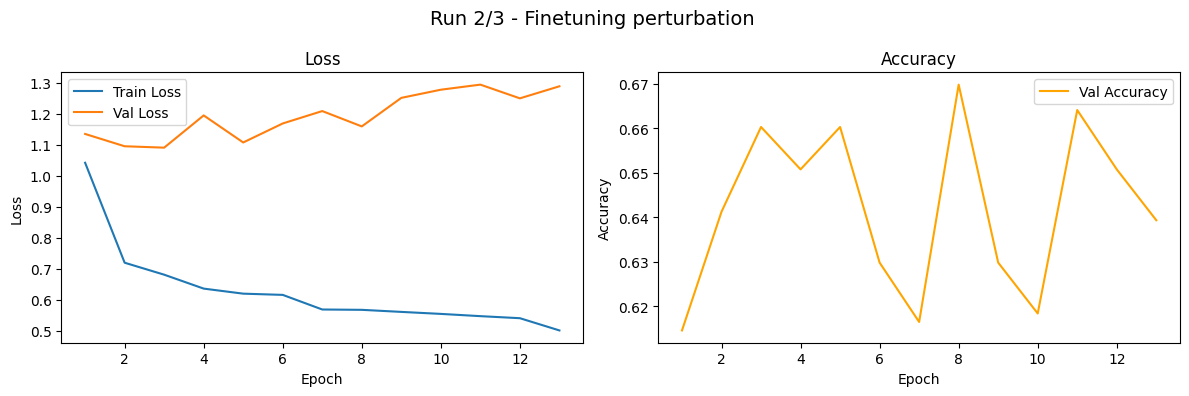

Memory cleaned after run 2

Run 3/3
Epoch [1/50] | Train Loss: 1.0531 | Val Loss: 1.1111 | Val Acc: 0.6508
Best model + history saved
Epoch [2/50] | Train Loss: 0.7398 | Val Loss: 1.0592 | Val Acc: 0.6240
Best model + history saved
Epoch [3/50] | Train Loss: 0.6599 | Val Loss: 1.1476 | Val Acc: 0.6489
Epoch [4/50] | Train Loss: 0.6576 | Val Loss: 1.2342 | Val Acc: 0.6660
Epoch [5/50] | Train Loss: 0.6332 | Val Loss: 1.0922 | Val Acc: 0.6489
Epoch [6/50] | Train Loss: 0.6041 | Val Loss: 1.1601 | Val Acc: 0.6622
Epoch [7/50] | Train Loss: 0.5664 | Val Loss: 1.0969 | Val Acc: 0.6527
Epoch [8/50] | Train Loss: 0.5908 | Val Loss: 1.1824 | Val Acc: 0.6393
Epoch [9/50] | Train Loss: 0.5529 | Val Loss: 1.1438 | Val Acc: 0.6584
Epoch [10/50] | Train Loss: 0.5660 | Val Loss: 1.2163 | Val Acc: 0.6374
Epoch [11/50] | Train Loss: 0.5333 | Val Loss: 1.2106 | Val Acc: 0.6584
Epoch [12/50] | Train Loss: 0.5315 | Val Loss: 1.1541 | Val Acc: 0.6431
Early stopping triggered

Run 3 finished in 14.89 minut

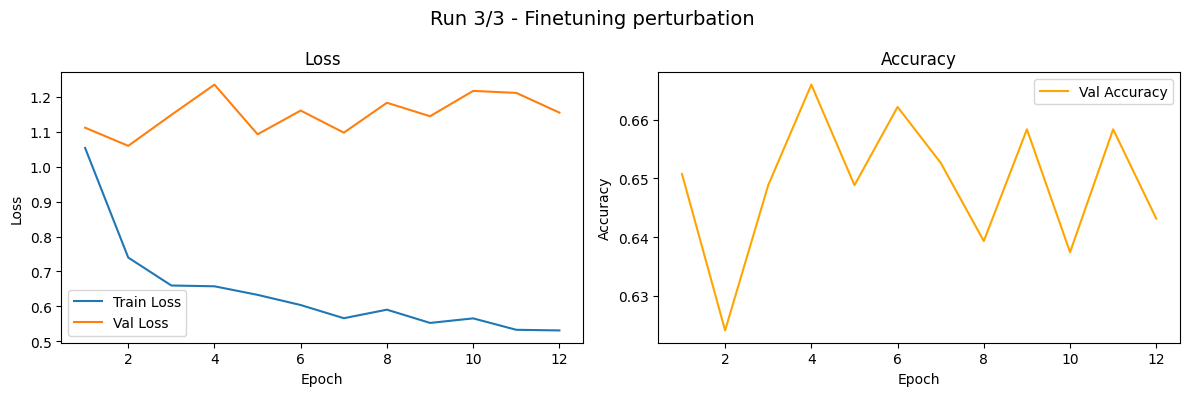

Memory cleaned after run 3


In [13]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

best_lr_head = 0.0004615619914925977

NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    # Load base model fresh each run
    wrapper_model = CrossAttentionModel(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_1_multimodal_best_run_3_stage2.pt",
        map_location=device,
        weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()

    # only unfreeze the classification head:
    for param in wrapper_model.vit.parameters():
        param.requires_grad = False

    wrapper_model.head[-1].reset_parameters()

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_head)

    wrapper_model, history = train_model_multimodal(
        wrapper_model, train_loader, val_loader, criterion,
        optimizer, device, epochs=50, patience=10,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_perturbation_attribute_unlearning_age_head_run{run_idx}_2.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")

    all_histories[run_idx] = {
        "train_loss": history["train_loss"],
        "val_loss":   history["val_loss"],
        "val_acc":    history["val_acc"],
    }

    # Plot
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Run {run_idx}/{NUM_RUNS} - Finetuning perturbation ", fontsize=14)

    axes[0].plot(epochs_x, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_x, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs_x, history["val_acc"], label="Val Accuracy", color="orange")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Clean up
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")

## (2) Fine-tuning with perturbations full body

Using device: cuda

Run 1/3
Epoch [1/50] | Train Loss: 2.1662 | Val Loss: 1.8572 | Val Acc: 0.5267
Best model + history saved
Epoch [2/50] | Train Loss: 1.8447 | Val Loss: 1.7342 | Val Acc: 0.5725
Best model + history saved
Epoch [3/50] | Train Loss: 1.6625 | Val Loss: 1.5419 | Val Acc: 0.6183
Best model + history saved
Epoch [4/50] | Train Loss: 1.5224 | Val Loss: 1.4861 | Val Acc: 0.6202
Best model + history saved
Epoch [5/50] | Train Loss: 1.4238 | Val Loss: 1.3761 | Val Acc: 0.6355
Best model + history saved
Epoch [6/50] | Train Loss: 1.3044 | Val Loss: 1.3606 | Val Acc: 0.6279
Best model + history saved
Epoch [7/50] | Train Loss: 1.2185 | Val Loss: 1.3030 | Val Acc: 0.6374
Best model + history saved
Epoch [8/50] | Train Loss: 1.1465 | Val Loss: 1.3292 | Val Acc: 0.6469
Epoch [9/50] | Train Loss: 1.0618 | Val Loss: 1.4000 | Val Acc: 0.6145
Epoch [10/50] | Train Loss: 1.0017 | Val Loss: 1.2101 | Val Acc: 0.6508
Best model + history saved
Epoch [11/50] | Train Loss: 0.9371 | Val Loss

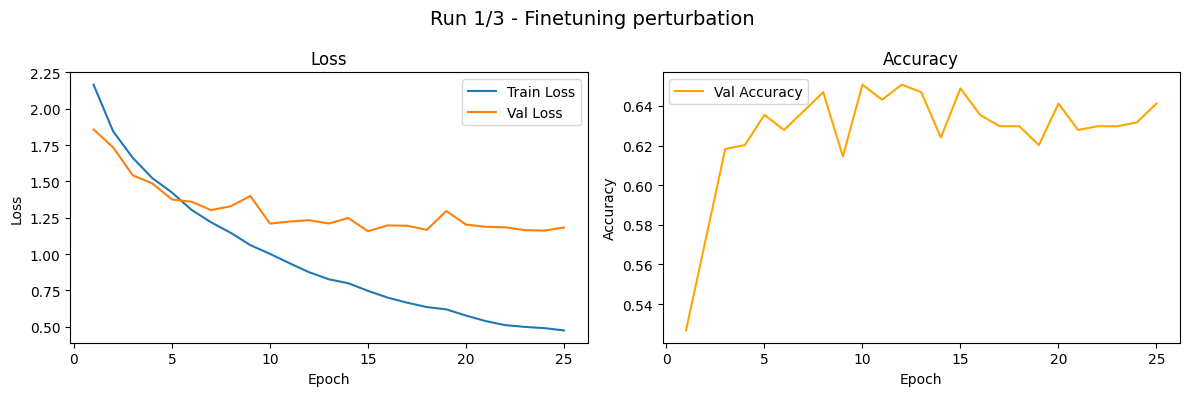

Memory cleaned after run 1

Run 2/3
Epoch [1/50] | Train Loss: 2.2264 | Val Loss: 2.0945 | Val Acc: 0.3149
Best model + history saved
Epoch [2/50] | Train Loss: 1.9287 | Val Loss: 1.8074 | Val Acc: 0.5553
Best model + history saved
Epoch [3/50] | Train Loss: 1.6883 | Val Loss: 1.6809 | Val Acc: 0.5916
Best model + history saved
Epoch [4/50] | Train Loss: 1.5300 | Val Loss: 1.5281 | Val Acc: 0.6183
Best model + history saved
Epoch [5/50] | Train Loss: 1.3885 | Val Loss: 1.4305 | Val Acc: 0.6336
Best model + history saved
Epoch [6/50] | Train Loss: 1.2533 | Val Loss: 1.4586 | Val Acc: 0.5954
Epoch [7/50] | Train Loss: 1.1404 | Val Loss: 1.3467 | Val Acc: 0.6336
Best model + history saved
Epoch [8/50] | Train Loss: 1.0594 | Val Loss: 1.3512 | Val Acc: 0.6240
Epoch [9/50] | Train Loss: 0.9778 | Val Loss: 1.3091 | Val Acc: 0.6450
Best model + history saved
Epoch [10/50] | Train Loss: 0.9154 | Val Loss: 1.3194 | Val Acc: 0.6260
Epoch [11/50] | Train Loss: 0.8468 | Val Loss: 1.2612 | Val Acc:

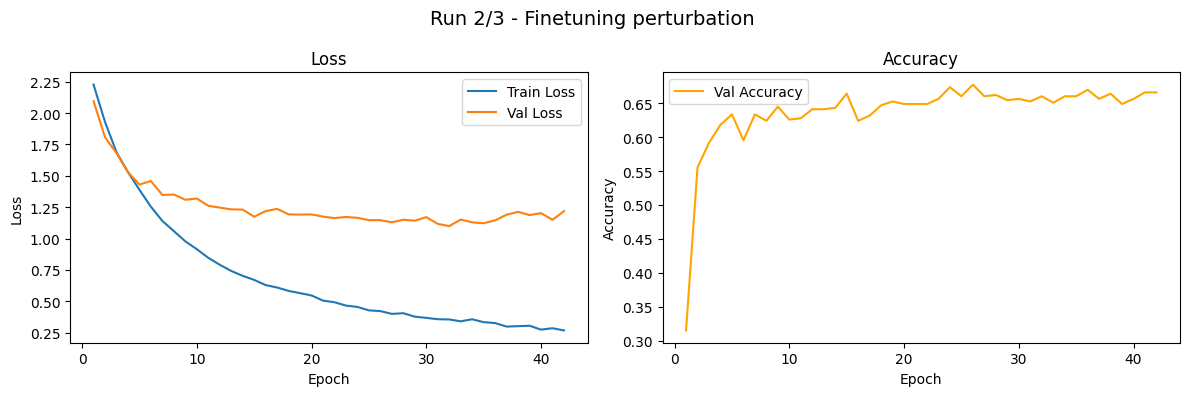

Memory cleaned after run 2

Run 3/3
Epoch [1/50] | Train Loss: 2.3853 | Val Loss: 2.1399 | Val Acc: 0.4427
Best model + history saved
Epoch [2/50] | Train Loss: 2.0954 | Val Loss: 2.0435 | Val Acc: 0.5191
Best model + history saved
Epoch [3/50] | Train Loss: 1.8883 | Val Loss: 1.7985 | Val Acc: 0.5878
Best model + history saved
Epoch [4/50] | Train Loss: 1.7290 | Val Loss: 1.6701 | Val Acc: 0.5973
Best model + history saved
Epoch [5/50] | Train Loss: 1.6004 | Val Loss: 1.6629 | Val Acc: 0.5954
Best model + history saved
Epoch [6/50] | Train Loss: 1.4680 | Val Loss: 1.5716 | Val Acc: 0.6317
Best model + history saved
Epoch [7/50] | Train Loss: 1.3739 | Val Loss: 1.4958 | Val Acc: 0.6260
Best model + history saved
Epoch [8/50] | Train Loss: 1.2832 | Val Loss: 1.4390 | Val Acc: 0.6240
Best model + history saved
Epoch [9/50] | Train Loss: 1.2000 | Val Loss: 1.4089 | Val Acc: 0.6107
Best model + history saved
Epoch [10/50] | Train Loss: 1.1319 | Val Loss: 1.3908 | Val Acc: 0.6260
Best model

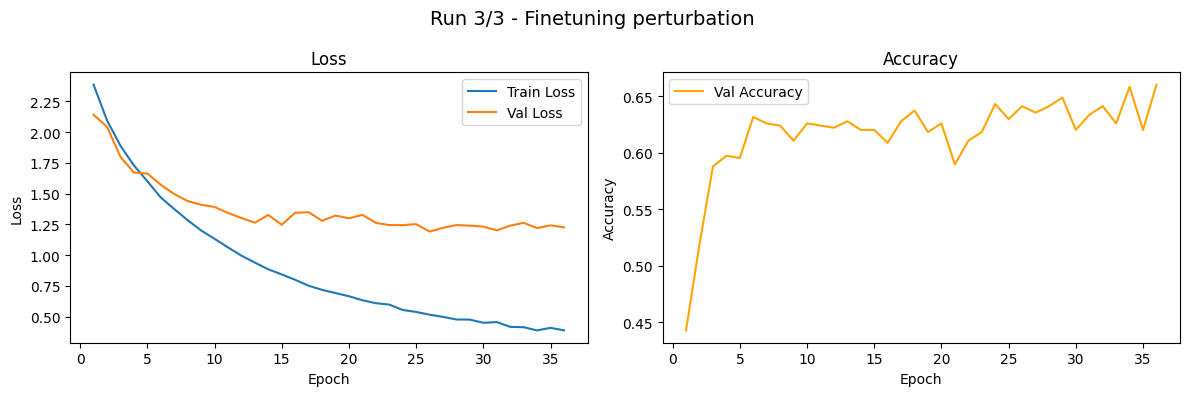

Memory cleaned after run 3


In [14]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

best_lr_full = 1.1526026851977796e-05

NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    # Load base model fresh each run
    wrapper_model = CrossAttentionModel(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_1_multimodal_best_run_3_stage2.pt",
        map_location=device,
        weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()

    # unfreeze all layers:
    for param in wrapper_model.vit.parameters():
        param.requires_grad = True

    wrapper_model.head[-1].reset_parameters()

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_full)

    wrapper_model, history = train_model_multimodal(
        wrapper_model, train_loader, val_loader, criterion,
        optimizer, device, epochs=50, patience=10,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_perturbation_attribute_unlearning_age_full_run{run_idx}_2.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")

    all_histories[run_idx] = {
        "train_loss": history["train_loss"],
        "val_loss":   history["val_loss"],
        "val_acc":    history["val_acc"],
    }

    # Plot
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Run {run_idx}/{NUM_RUNS} - Finetuning perturbation ", fontsize=14)

    axes[0].plot(epochs_x, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_x, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs_x, history["val_acc"], label="Val Accuracy", color="orange")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Clean up
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")

## (3) Fine-tuning 4 epochs

Using device: cuda

Run 1/3
Epoch [1/4] | Train Loss: 0.6539 | Val Loss: 1.0196 | Val Acc: 0.6508
Best model + history saved
Epoch [2/4] | Train Loss: 0.6000 | Val Loss: 1.0004 | Val Acc: 0.6698
Best model + history saved
Epoch [3/4] | Train Loss: 0.5642 | Val Loss: 1.0429 | Val Acc: 0.6565
Epoch [4/4] | Train Loss: 0.5246 | Val Loss: 1.0550 | Val Acc: 0.6641
Final epoch model saved

Run 1 finished in 12.12 minutes


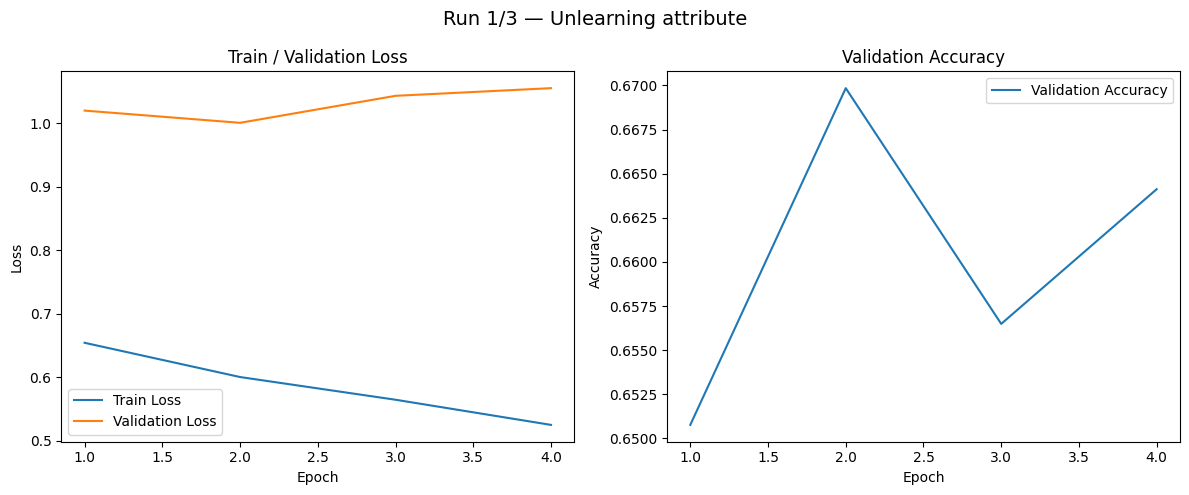

Memory cleaned after run 1

Run 2/3
Epoch [1/4] | Train Loss: 0.6475 | Val Loss: 1.0050 | Val Acc: 0.6603
Best model + history saved
Epoch [2/4] | Train Loss: 0.5916 | Val Loss: 1.0063 | Val Acc: 0.6603
Epoch [3/4] | Train Loss: 0.5658 | Val Loss: 1.0334 | Val Acc: 0.6641
Epoch [4/4] | Train Loss: 0.5390 | Val Loss: 1.0327 | Val Acc: 0.6508
Final epoch model saved

Run 2 finished in 12.00 minutes


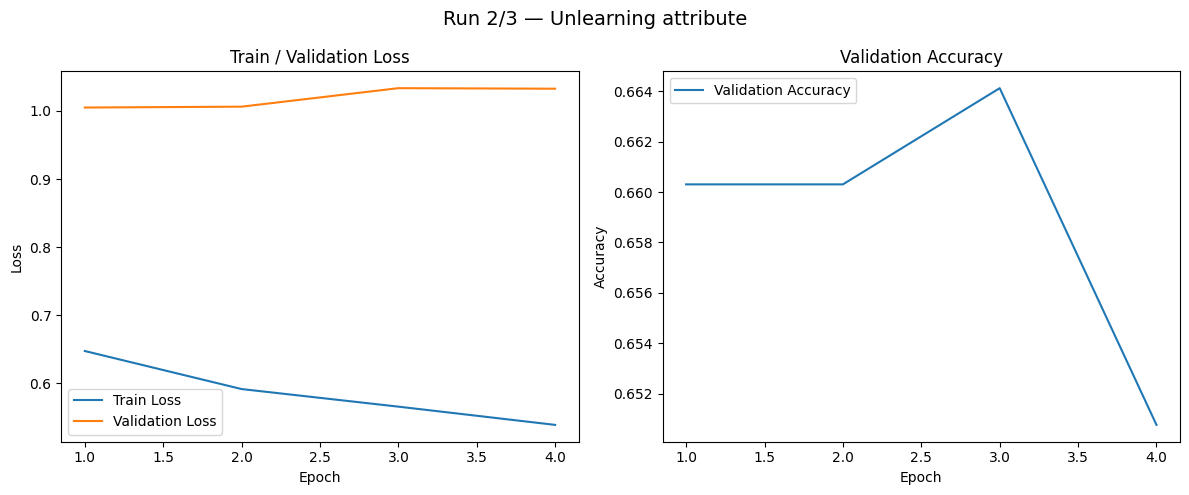

Memory cleaned after run 2

Run 3/3
Epoch [1/4] | Train Loss: 0.6679 | Val Loss: 1.0322 | Val Acc: 0.6450
Best model + history saved
Epoch [2/4] | Train Loss: 0.6025 | Val Loss: 1.0106 | Val Acc: 0.6718
Best model + history saved
Epoch [3/4] | Train Loss: 0.5660 | Val Loss: 1.0149 | Val Acc: 0.6584
Epoch [4/4] | Train Loss: 0.5233 | Val Loss: 1.0197 | Val Acc: 0.6527
Final epoch model saved

Run 3 finished in 12.56 minutes


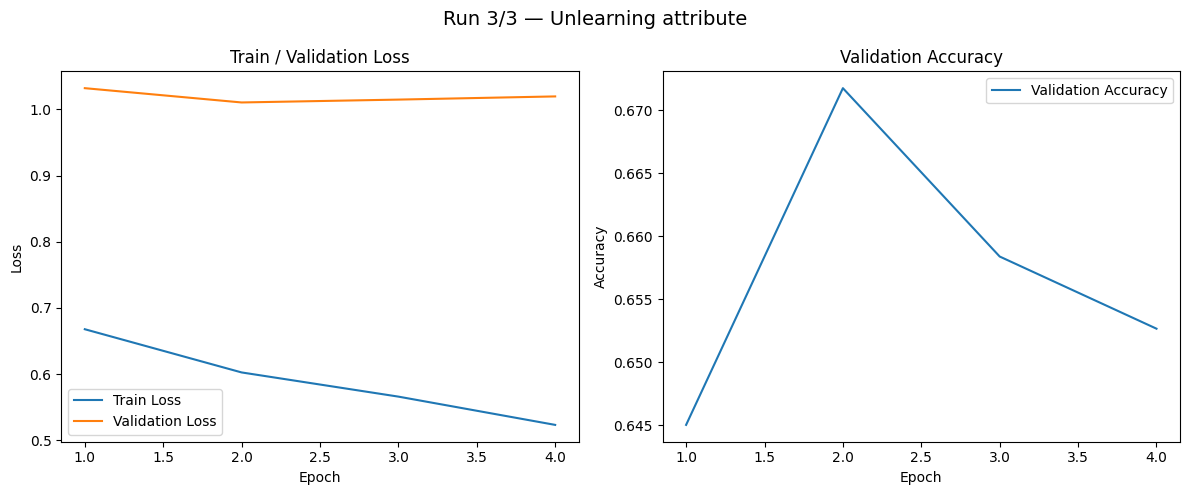

Memory cleaned after run 3


In [15]:
from VitClassifier_1_defnitions import *
import time
import torch
import matplotlib.pyplot as plt
import gc
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

SAVE_EPOCH = 4
best_lr_full = 1.1526026851977796e-05


NUM_RUNS = 3
all_histories = {}

for run_idx in range(1, NUM_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"Run {run_idx}/{NUM_RUNS}")
    print(f"{'='*60}")

    start_time = time.time()

    wrapper_model = CrossAttentionModel(
        metadata_dim=train_dataset.metadata_dim, num_classes=11
    ).to(device)
    checkpoint = torch.load(
        CHECKPOINT_DIR + "/Cross_1_multimodal_best_run_3_stage2.pt",
        map_location=device, weights_only=False
    )
    wrapper_model.load_state_dict(checkpoint["model_state"])

    criterion = nn.CrossEntropyLoss()
     # unfreeze all layers:
    for param in wrapper_model.vit.parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW(wrapper_model.parameters(), lr=best_lr_full)


    wrapper_model, history = train_model_multimodal(
        model=wrapper_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=SAVE_EPOCH,
        save_path=f"{CHECKPOINT_DIR}/Finetuning_attribute_unlearning_age_4_epochs_run{run_idx}_2_2.pt"
    )

    end_time = time.time()
    print(f"\nRun {run_idx} finished in {(end_time - start_time)/60:.2f} minutes")


    # --- Plot immediately ---
    epochs_x = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
       f"Run {run_idx}/{NUM_RUNS} — Unlearning attribute",
       fontsize=14
    )

    # Loss plot

    axes[0].plot(
       epochs_x,
       history["train_loss"],
       label="Train Loss"
    )

    axes[0].plot(
      epochs_x,
      history["val_loss"],
      label="Validation Loss"
    )

    axes[0].set_title("Train / Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # -----------------------------
    # Accuracy plot
    # -----------------------------

    axes[1].plot(
        epochs_x,
        history["val_acc"],
        label="Validation Accuracy"
    )

    axes[1].set_title("Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Clean up ---
    del wrapper_model, optimizer, criterion, history
    torch.cuda.empty_cache()
    gc.collect()
    print(f"Memory cleaned after run {run_idx}")